# LPB method comparison at 90% target coverage

This notebook reads one or more merged CSV/TSV result files, keeps only the **90% target coverage** rows, and compares:

- **Static** (`optimized`)
- **Locally adaptive**, separated by hard-floor, trajectory-mixture, no-floor, and CRC variants
- **Random-family policies**, separating the legacy trajectory-mixture allocator (not constant final probabilities) from true hard-floor, no-floor, and CRC constant-policy variants when present
- **DAPRO**

For each requested metric, it creates a publication-ready boxplot and an OpenReview-compatible Markdown table:

1. Coverage rate
2. Signed coverage-rate deviation from the 90% target
3. Coverage variance
4. LPB variance (`size`)
5. Mean inverse-probability weight, mean $A_i/\pi_i$, and mean $A_i(1/\pi_i-1)$
6. Expected budget per sample and the expected-budget feasibility flag
7. Realized consumed budget per calibration sample, reported separately

The notebook also produces one concluding Markdown table with one row per method and columns for coverage and its variance, mean weight, both $A$-weighted metrics, expected-budget feasibility, realized budget, and empirical coverage feasibility.

**Variance figure convention.** A method's sample variance is one scalar, so a literal boxplot of that scalar is not defined. Each plotted squared deviation is multiplied by $n/(n-1)$, so the arithmetic mean of the plotted contributions equals the unbiased across-replicate sample variance (`ddof=1`) in the table.


In [1]:
from pathlib import Path
import glob
import os
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display


# Make the notebook work from either the repository root or notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

# -----------------------------------------------------------------------------
# INPUT CONFIGURATION
# -----------------------------------------------------------------------------
# Option A: list files directly.
CSV_PATHS = [
    PROJECT_ROOT / "results" / "merged_calibration_dfs" / "dataset_toxicity_attack_toxic_attack_qwen25_14b_instruct_lm_target_qwen25_14b_instruct_judge_detoxify_20.0_3000_0.56_10.0__final_matrix_100_tox_v2" / "all_df.csv",
    PROJECT_ROOT / "results" / "merged_calibration_dfs" / "dataset_toxicity_attack_toxic_attack_qwen25_14b_instruct_lm_target_qwen25_14b_instruct_judge_detoxify_20.0_3000_0.56_10.0__phase1_regularized_grid_100_tox_v2" / "all_df.csv",
]

# Option B: put the result files in results_for_rebuttal/ or edit this glob.
CSV_GLOBS = []
# dataset_autoif_attack_autoif_helper_qwen25_14b_instruct_lm_target_qwen25_14b_instruct_judge_autoif_20.0_3000_0.56_10.0
# toxicity_qwen2
# dataset_autoif_attack_autoif_helper_qwen25_14b_instruct_lm_target_qwen25_14b_instruct_judge_autoif_20.0_3000_0.97_10.0
# Optional command-line/Jupyter override, useful for reproducible execution:
#   LPB_CSV_PATHS="/path/a.csv:/path/b.csv" jupyter nbconvert --execute ...
env_paths = [p for p in os.environ.get("LPB_CSV_PATHS", "").split(os.pathsep) if p]
if env_paths:
    CSV_PATHS = [Path(p) for p in env_paths]
    CSV_GLOBS = []

TARGET_COVERAGE = 0.90
TARGET_ATOL = 5e-4
BUDGET_ATOL = 1e-7
DEVIATION_MODE = "signed"  # This notebook reports coverage - target in percentage points.
ALLOW_MULTIPLE_RAW_NAMES_PER_METHOD = False

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "figures" / "lpb_90pct_method_metrics"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

METHOD_CANDIDATES = {
    "Static": [
        "static",
        "optimized",
        "static_optimized",
        "calibration_optimized_allocation",
        "calibration_static_optimized_allocation",
    ],
    # This raw name denotes the hard-floor default in the current registry.
    # For legacy CSVs lacking `terminal_floor_mode`, verify source provenance.
    "Local (hard floor; current default)": [
        "calibration_adaptive_optimized_allocation",
    ],
    "Local (trajectory-mixture floor)": [
        "calibration_adaptive_optimized_mixture_terminal_floor_0p005_allocation",
    ],
    "Local (no terminal floor)": [
        "calibration_adaptive_optimized_no_terminal_floor_allocation",
    ],
    "Local (hard floor + CRC budget)": [
        "calibration_adaptive_optimized_crc_allocation",
    ],
    # Historical default: the base continuation probability is constant,
    # but the executed cumulative trajectory is mixed with epsilon. It is
    # therefore not the true no-floor constant-probability policy.
    "Random (legacy trajectory-mixture floor)": [
        "calibration_random_adaptive_optimized_allocation",
    ],
    "Random (hard terminal floor)": [
        "calibration_random_adaptive_optimized_hard_terminal_floor_0p005_allocation",
    ],
    "Random (constant; no terminal floor)": [
        "calibration_random_adaptive_optimized_no_terminal_floor_allocation",
    ],
    "Random (hard floor + CRC budget)": [
        "calibration_random_adaptive_optimized_hard_terminal_floor_0p005_crc_allocation",
    ],
    "DAPRO (global weight; N1=100)": [
        "dapro",
        "calibration_projected_optimization_platt_prob_allocation",
        "calibration_projected_optimization_direct_time_prob_allocation",
    ],
    "DAPRO (global weight; N1=200)": [
        "calibration_projected_optimization_direct_time_prob_n1_200_allocation",
    ],
    "DAPRO (cumulative target-A)": [
        "calibration_projected_optimization_cumulative_platt_prob_a_target_raw_alpha_0p10_allocation",
    ],
    "Target-A raw (N1=100)": [
        "calibration_projected_optimization_direct_time_prob_a_target_raw_alpha_0p10_allocation",
    ],
    "Target-A raw (N1=200)": [
        "calibration_projected_optimization_direct_time_prob_a_target_raw_alpha_0p10_n1_200_allocation",
    ],
    "Target-A raw + global 0.001 (N1=100)": [
        "calibration_projected_optimization_direct_time_prob_a_target_raw_regularized_global_0p001_alpha_0p10_allocation",
    ],
    "Target-A raw + global 0.001 (N1=200)": [
        "calibration_projected_optimization_direct_time_prob_a_target_raw_regularized_global_0p001_alpha_0p10_n1_200_allocation",
    ],
    "Target-A band + global 0.01 (N1=100)": [
        "calibration_projected_optimization_direct_time_prob_a_band_0p07_0p13_global_0p010_allocation",
    ],
    "Target-A band + global 0.01 (N1=200)": [
        "calibration_projected_optimization_direct_time_prob_a_band_0p07_0p13_global_0p010_n1_200_allocation",
    ],
    "Target-A Phase-I (N1=100)": [
        "calibration_projected_optimization_direct_time_prob_a_target_phase1_unweighted_alpha_0p10_allocation",
    ],
    "Target-A Phase-I (N1=200)": [
        "calibration_projected_optimization_direct_time_prob_a_target_phase1_unweighted_alpha_0p10_n1_200_allocation",
    ],
    "Target-A Phase-I + global 0.001 (N1=100)": [
        "calibration_projected_optimization_direct_time_prob_a_target_phase1_unweighted_regularized_global_0p001_alpha_0p10_allocation",
    ],
    "Target-A Phase-I + global 0.001 (N1=200)": [
        "calibration_projected_optimization_direct_time_prob_a_target_phase1_unweighted_regularized_global_0p001_alpha_0p10_n1_200_allocation",
    ],
    "Target-A Phase-I + global 0.01 (N1=100)": [
        "calibration_projected_optimization_direct_time_prob_a_target_phase1_unweighted_regularized_global_0p010_alpha_0p10_allocation",
    ],
    "Target-A Phase-I + global 0.01 (N1=200)": [
        "calibration_projected_optimization_direct_time_prob_a_target_phase1_unweighted_regularized_global_0p010_alpha_0p10_n1_200_allocation",
    ],
    "Target-A Phase-I + global 0.05 (N1=100)": [
        "calibration_projected_optimization_direct_time_prob_a_target_phase1_unweighted_regularized_global_0p050_alpha_0p10_allocation",
    ],
    "Target-A Phase-I + global 0.05 (N1=200)": [
        "calibration_projected_optimization_direct_time_prob_a_target_phase1_unweighted_regularized_global_0p050_alpha_0p10_n1_200_allocation",
    ],
}
METHOD_ORDER = list(METHOD_CANDIDATES)
# Floor/CRC ablations are optional so older or deliberately partial result
# files remain usable. Present variants are always kept separate.
OPTIONAL_METHODS = {
    "Local (trajectory-mixture floor)",
    "Local (no terminal floor)",
    "Local (hard floor + CRC budget)",
    "Random (hard terminal floor)",
    "Random (constant; no terminal floor)",
    "Random (hard floor + CRC budget)",
    "DAPRO (global weight; N1=200)",
    "DAPRO (cumulative target-A)",
    "Target-A raw (N1=100)",
    "Target-A raw (N1=200)",
    "Target-A raw + global 0.001 (N1=100)",
    "Target-A raw + global 0.001 (N1=200)",
    "Target-A band + global 0.01 (N1=100)",
    "Target-A band + global 0.01 (N1=200)",
    "Target-A Phase-I (N1=100)",
    "Target-A Phase-I (N1=200)",
    "Target-A Phase-I + global 0.001 (N1=100)",
    "Target-A Phase-I + global 0.001 (N1=200)",
    "Target-A Phase-I + global 0.01 (N1=100)",
    "Target-A Phase-I + global 0.01 (N1=200)",
    "Target-A Phase-I + global 0.05 (N1=100)",
    "Target-A Phase-I + global 0.05 (N1=200)",
}

sns.set_theme(style="whitegrid", context="talk")
METHOD_PALETTE = dict(zip(METHOD_ORDER, sns.color_palette("colorblind", len(METHOD_ORDER))))

print(f"Target coverage: {TARGET_COVERAGE:.0%}")
print(f"Figures and tables will be written to: {OUTPUT_DIR}")

Target coverage: 90%
Figures and tables will be written to: C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\lpb_90pct_method_metrics


## Load, normalize, and validate the result files

The loader auto-detects comma- or tab-separated files. Coverage and target coverage may be stored as fractions (`0.90`) or percentages (`90`). Exact duplicate rows are removed. A replicate is identified by `(dataset setup, method, seed)`; overlapping files containing the same replicate are rejected instead of being pooled as independent observations.


In [2]:
def _resolve_input_paths(csv_paths, csv_globs):
    resolved = []
    for path in csv_paths:
        resolved.append(Path(path).expanduser().resolve())
    for pattern in csv_globs:
        resolved.extend(Path(p).resolve() for p in glob.glob(pattern, recursive=True))
    # Stable de-duplication.
    unique = []
    seen = set()
    for path in resolved:
        if path not in seen:
            seen.add(path)
            unique.append(path)
    missing = [path for path in unique if not path.exists()]
    if missing:
        raise FileNotFoundError("Input files not found:\n" + "\n".join(map(str, missing)))
    if not unique:
        raise FileNotFoundError(
            "No CSV/TSV files were found. Add paths to CSV_PATHS, edit CSV_GLOBS, "
            "or set the LPB_CSV_PATHS environment variable."
        )
    return unique


def _read_delimited(path):
    # sep=None with the Python engine detects both commas and tabs.
    try:
        return pd.read_csv(path, sep=None, engine="python")
    except Exception as exc:
        raise ValueError(f"Could not parse {path}: {exc}") from exc


def _coerce_fraction(series, column_name):
    text = series.astype(str).str.strip()
    has_percent = text.str.endswith("%")
    numeric = pd.to_numeric(text.str.rstrip("%"), errors="coerce")
    numeric.loc[has_percent] = numeric.loc[has_percent] / 100.0
    finite = numeric[np.isfinite(numeric)]
    if not finite.empty and finite.quantile(0.95) > 1.5:
        numeric = numeric / 100.0
    return numeric


def _normalize_method_name(value):
    value = str(value).strip().lower()
    value = re.sub(r"[^a-z0-9]+", "_", value).strip("_")
    return value


input_paths = _resolve_input_paths(CSV_PATHS, CSV_GLOBS)
frames = []
for path in input_paths:
    frame = _read_delimited(path)
    stripped_columns = frame.columns.astype(str).str.strip()
    if stripped_columns.duplicated().any():
        duplicates = stripped_columns[stripped_columns.duplicated()].tolist()
        raise ValueError(
            f"Column-name trimming created duplicate columns in {path}: {duplicates}"
        )
    frame.columns = stripped_columns
    frame["source_file"] = path.name
    frame["source_path"] = str(path)
    frames.append(frame)

raw_df = pd.concat(frames, ignore_index=True, sort=False)
rows_before = len(raw_df)
raw_df = raw_df.drop_duplicates().copy()
exact_duplicates_removed = rows_before - len(raw_df)

required_columns = {
    "seed", "calibration_name", "target_coverage", "coverage", "size",
    "mean_weight", "mean_inverse_probability_minus_one", "budget_used",
    "configured_cal_size", "configured_budget_per_sample",
    "mean_a_weighted_inverse_probability",
    "mean_a_weighted_inverse_probability_minus_one",
    "all_observed_jailbreaks",
}
missing_columns = required_columns.difference(raw_df.columns)
if missing_columns:
    raise KeyError(
        f"Missing required columns: {sorted(missing_columns)}. "
        f"Available columns: {sorted(raw_df.columns)}"
    )

raw_df["target_coverage"] = _coerce_fraction(raw_df["target_coverage"], "target_coverage")
raw_df["coverage"] = _coerce_fraction(raw_df["coverage"], "coverage")
numeric_columns = [
    "size", "mean_weight", "mean_inverse_probability_minus_one",
    "budget_used", "configured_cal_size", "configured_budget_per_sample",
    "mean_a_weighted_inverse_probability",
    "mean_a_weighted_inverse_probability_minus_one",
    "all_observed_jailbreaks", "total_expected_budget_per_sample",
    "static_expected_cost_per_sample", "phase2_sample_count",
    "phase2_realized_cost_per_sample", "phase2_expected_cost_per_sample",
]
for column in numeric_columns:
    if column in raw_df:
        raw_df[column] = pd.to_numeric(raw_df[column], errors="coerce")

# Experiment suffixes identify ablations, not independent datasets. Strip the
# suffix so overlapping files from the same dataset/setup share one key.
fallback_dataset_id = raw_df["source_path"].map(
    lambda value: Path(value).parent.name.split("__", 1)[0]
)
if "experiment_name" in raw_df:
    experiment_dataset_id = (
        raw_df["experiment_name"].astype("string").str.split("__", n=1).str[0]
    )
    raw_df["dataset_id"] = experiment_dataset_id.fillna(fallback_dataset_id)
else:
    raw_df["dataset_id"] = fallback_dataset_id

available_raw_names = sorted(raw_df["calibration_name"].dropna().astype(str).unique())
available_by_normalized = {}
for raw_name in available_raw_names:
    available_by_normalized.setdefault(_normalize_method_name(raw_name), []).append(raw_name)

resolved_raw_names = {}
for display_name, candidates in METHOD_CANDIDATES.items():
    matches = []
    for candidate in candidates:
        matches.extend(available_by_normalized.get(_normalize_method_name(candidate), []))
    matches = list(dict.fromkeys(matches))
    if not matches and display_name in OPTIONAL_METHODS:
        continue
    if not matches:
        raise ValueError(
            f"Could not resolve method {display_name!r}. Candidate names: {candidates}. "
            f"Available calibration_name values: {available_raw_names}"
        )
    if len(matches) > 1 and not ALLOW_MULTIPLE_RAW_NAMES_PER_METHOD:
        raise ValueError(
            f"Method {display_name!r} matched multiple raw names: {matches}. "
            "This can mix distinct configurations. Narrow METHOD_CANDIDATES or set "
            "ALLOW_MULTIPLE_RAW_NAMES_PER_METHOD=True deliberately."
        )
    resolved_raw_names[display_name] = matches

# Drop absent optional variants from all downstream tables and plots.
METHOD_ORDER = [name for name in METHOD_ORDER if name in resolved_raw_names]
METHOD_PALETTE = dict(
    zip(METHOD_ORDER, sns.color_palette("colorblind", len(METHOD_ORDER)))
)

raw_to_display = {
    raw_name: display_name
    for display_name, raw_names in resolved_raw_names.items()
    for raw_name in raw_names
}

analysis_df = raw_df.loc[
    raw_df["calibration_name"].isin(raw_to_display)
    & np.isclose(raw_df["target_coverage"], TARGET_COVERAGE, atol=TARGET_ATOL, rtol=0)
].copy()
analysis_df["Method"] = analysis_df["calibration_name"].map(raw_to_display)
analysis_df["replicate_id"] = (
    analysis_df["dataset_id"].astype(str) + "::seed=" + analysis_df["seed"].astype(str)
)

metric_columns = [
    "coverage", "size", "mean_weight", "mean_inverse_probability_minus_one",
    "mean_a_weighted_inverse_probability",
    "mean_a_weighted_inverse_probability_minus_one",
    "all_observed_jailbreaks", "budget_used", "configured_cal_size",
    "configured_budget_per_sample",
]
nonfinite_mask = ~np.isfinite(
    analysis_df[metric_columns].to_numpy(dtype=float)
).all(axis=1)
if nonfinite_mask.any():
    bad = analysis_df.loc[
        nonfinite_mask, ["source_path", "seed", "Method", *metric_columns]
    ]
    raise ValueError(
        "Found non-finite required metrics at the 90% target:\n"
        + bad.to_string(index=False)
    )
if (analysis_df["configured_cal_size"] <= 0).any():
    raise ValueError("`configured_cal_size` must be positive.")

# Exactly one selected row per dataset/method/seed is required. In particular,
# do not count the same seeded replicate twice merely because it was merged
# into two experiment-suffix files.
key_columns = ["dataset_id", "seed", "Method"]
duplicate_keys = analysis_df.duplicated(key_columns, keep=False)
if duplicate_keys.any():
    conflicts = analysis_df.loc[
        duplicate_keys,
        ["source_path", *key_columns, "calibration_name", "target_coverage", *metric_columns],
    ].sort_values(key_columns)
    raise ValueError(
        "More than one 90%-target row exists for a dataset/method/seed key. "
        "Overlapping experiment files are not independent replicates:\n"
        + conflicts.to_string(index=False)
    )

dataset_ids = analysis_df["dataset_id"].dropna().unique()
if len(dataset_ids) != 1:
    raise ValueError(
        "This notebook compares one dataset/setup at a time; refusing to pool "
        f"coverage variance across datasets: {dataset_ids.tolist()}"
    )
if analysis_df["configured_cal_size"].nunique() != 1:
    raise ValueError("Selected rows disagree on `configured_cal_size`.")
if analysis_df["configured_budget_per_sample"].nunique() != 1:
    raise ValueError("Selected rows disagree on the configured budget per sample.")

method_counts = analysis_df.groupby("Method")["replicate_id"].nunique().reindex(METHOD_ORDER)
if method_counts.isna().any() or (method_counts == 0).any():
    raise ValueError(f"At least one requested method has no rows: {method_counts.to_dict()}")
if (method_counts < 2).any():
    warnings.warn(
        "At least one method has fewer than two replicates; sample variance will be undefined."
    )

# Metric identities at the selected LPB. Phase-I rows are fully observed and
# therefore correctly enter the all-calibration averages with pi_i = 1.
weight_identity_error = (
    analysis_df["mean_weight"] - 1
    - analysis_df["mean_inverse_probability_minus_one"]
)
if not np.allclose(weight_identity_error, 0, atol=1e-8, rtol=1e-8):
    raise ValueError("`mean_weight - 1` identity failed.")
analysis_df["mean_a"] = (
    analysis_df["all_observed_jailbreaks"]
    / analysis_df["configured_cal_size"]
)
a_identity_error = (
    analysis_df["mean_a_weighted_inverse_probability"]
    - analysis_df["mean_a"]
    - analysis_df["mean_a_weighted_inverse_probability_minus_one"]
)
if not np.allclose(a_identity_error, 0, atol=1e-8, rtol=1e-8):
    raise ValueError(
        "`mean(A/pi) = mean(A) + mean(A(1/pi-1))` identity failed."
    )
if (analysis_df["mean_a_weighted_inverse_probability_minus_one"] < -1e-10).any():
    raise ValueError("The selected-bound A-weighted variance proxy is negative.")

analysis_df["coverage_pct"] = 100.0 * analysis_df["coverage"]
analysis_df["coverage_meets_target"] = (
    analysis_df["coverage"] + TARGET_ATOL >= analysis_df["target_coverage"]
)
analysis_df["realized_budget_per_sample"] = (
    analysis_df["budget_used"] / analysis_df["configured_cal_size"]
)
analysis_df["realized_budget_exceeds_target"] = (
    analysis_df["realized_budget_per_sample"]
    > analysis_df["configured_budget_per_sample"] + BUDGET_ATOL
)

# Prefer the allocator's directly stored total expectation. The fallbacks only
# support legacy files that predate the common total-expected-budget field.
analysis_df["expected_budget_per_sample"] = np.nan
analysis_df["expected_budget_source"] = pd.NA
if "total_expected_budget_per_sample" in analysis_df:
    known = analysis_df["total_expected_budget_per_sample"].notna()
    analysis_df.loc[known, "expected_budget_per_sample"] = analysis_df.loc[
        known, "total_expected_budget_per_sample"
    ]
    analysis_df.loc[known, "expected_budget_source"] = "stored total expectation"
if "static_expected_cost_per_sample" in analysis_df:
    known = (
        analysis_df["expected_budget_per_sample"].isna()
        & analysis_df["static_expected_cost_per_sample"].notna()
    )
    analysis_df.loc[known, "expected_budget_per_sample"] = analysis_df.loc[
        known, "static_expected_cost_per_sample"
    ]
    analysis_df.loc[known, "expected_budget_source"] = "stored static expectation"
phase2_columns = {
    "phase2_sample_count", "phase2_realized_cost_per_sample",
    "phase2_expected_cost_per_sample",
}
if phase2_columns.issubset(analysis_df.columns):
    phase2_known = analysis_df[list(phase2_columns)].notna().all(axis=1)
    reconstructed_expected = (
        analysis_df["budget_used"]
        - analysis_df["phase2_realized_cost_per_sample"]
        * analysis_df["phase2_sample_count"]
        + analysis_df["phase2_expected_cost_per_sample"]
        * analysis_df["phase2_sample_count"]
    ) / analysis_df["configured_cal_size"]
    known = analysis_df["expected_budget_per_sample"].isna() & phase2_known
    analysis_df.loc[known, "expected_budget_per_sample"] = reconstructed_expected[known]
    analysis_df.loc[known, "expected_budget_source"] = "legacy phase-I/II reconstruction"
analysis_df["expected_budget_feasible"] = pd.array(
    [
        pd.NA if pd.isna(expected) else expected <= target + BUDGET_ATOL
        for expected, target in zip(
            analysis_df["expected_budget_per_sample"],
            analysis_df["configured_budget_per_sample"],
        )
    ],
    dtype="boolean",
)
if analysis_df["expected_budget_per_sample"].isna().any():
    missing_expected = sorted(
        analysis_df.loc[
            analysis_df["expected_budget_per_sample"].isna(), "Method"
        ].astype(str).unique()
    )
    warnings.warn(
        "Expected-budget metrics are unavailable for legacy methods: "
        f"{missing_expected}. Their feasibility is reported as unknown."
    )
analysis_df["coverage_deviation_pp"] = analysis_df["coverage_pct"] - 100.0 * TARGET_COVERAGE
def _unbiased_variance_contributions(values):
    count = values.notna().sum()
    if count < 2:
        return pd.Series(np.nan, index=values.index)
    return (values - values.mean()) ** 2 * count / (count - 1)

analysis_df["coverage_sq_deviation_pp2"] = analysis_df.groupby(
    "Method", observed=True
)["coverage_pct"].transform(_unbiased_variance_contributions)
analysis_df["lpb_sq_deviation"] = analysis_df.groupby(
    "Method", observed=True
)["size"].transform(_unbiased_variance_contributions)
analysis_df["Method"] = pd.Categorical(
    analysis_df["Method"], categories=METHOD_ORDER, ordered=True
)
analysis_df = analysis_df.sort_values(["Method", "source_file", "seed"]).reset_index(drop=True)

resolution_table = pd.DataFrame(
    {
        "Method": METHOD_ORDER,
        "calibration_name": [", ".join(resolved_raw_names[m]) for m in METHOD_ORDER],
        "Replicates": method_counts.reindex(METHOD_ORDER).astype(int).to_numpy(),
    }
)
print(f"Loaded {len(input_paths)} file(s), {len(analysis_df)} selected rows, "
      f"and removed {exact_duplicates_removed} exact duplicate row(s).")
display(resolution_table)


Loaded 2 file(s), 2500 selected rows, and removed 0 exact duplicate row(s).


,Method,calibration_name,Replicates
0,Static,calibration_optimized_allocation,100
1,Local (hard floor; current default),calibration_adaptive_optimized_allocation,100
2,Local (trajectory-mixture floor),calibration_adaptive_optimized_mixture_termina...,100
3,Local (no terminal floor),calibration_adaptive_optimized_no_terminal_flo...,100
4,Local (hard floor + CRC budget),calibration_adaptive_optimized_crc_allocation,100
5,Random (legacy trajectory-mixture floor),calibration_random_adaptive_optimized_allocation,100
6,Random (hard terminal floor),calibration_random_adaptive_optimized_hard_ter...,100
7,Random (constant; no terminal floor),calibration_random_adaptive_optimized_no_termi...,100
8,Random (hard floor + CRC budget),calibration_random_adaptive_optimized_hard_ter...,100
9,DAPRO (global weight; N1=100),calibration_projected_optimization_direct_time...,100


## Plotting and OpenReview table helpers

In [3]:
def _format_number(value, digits=3, signed=False):
    if pd.isna(value):
        return "—"
    pattern = f"{{:{'+' if signed else ''}.{digits}f}}"
    return pattern.format(float(value))


def _markdown_table(table, formats):
    columns = list(table.columns)
    lines = [
        "| " + " | ".join(columns) + " |",
        "|" + "|".join("---:" if i else "---" for i in range(len(columns))) + "|",
    ]
    for _, row in table.iterrows():
        rendered = []
        for column in columns:
            value = row[column]
            formatter = formats.get(column, str)
            rendered.append(formatter(value) if callable(formatter) else formatter.format(value))
        lines.append("| " + " | ".join(rendered) + " |")
    return "\n".join(lines)


def _publish_table(title, table, formats, slug, note=None):
    markdown = _markdown_table(table, formats)
    if note:
        markdown += "\n\n" + note
    display(Markdown(f"### {title}\n\n{markdown}"))
    print("Copy this block into OpenReview:\n")
    print("```markdown")
    print(markdown)
    print("```")
    (OUTPUT_DIR / f"table_{slug}.md").write_text(markdown + "\n", encoding="utf-8")
    return markdown


def _boxplot(data, y, ylabel, title, slug, reference=None, reference_label=None):
    fig, ax = plt.subplots(figsize=(9.2, 5.6))
    sns.boxplot(
        data=data,
        x="Method",
        y=y,
        hue="Method",
        order=METHOD_ORDER,
        hue_order=METHOD_ORDER,
        palette=METHOD_PALETTE,
        legend=False,
        width=0.58,
        showfliers=False,
        ax=ax,
    )
    sns.stripplot(
        data=data,
        x="Method",
        y=y,
        order=METHOD_ORDER,
        color="black",
        alpha=0.42,
        size=3.3,
        jitter=0.18,
        ax=ax,
    )
    if reference is not None:
        ax.axhline(
            reference,
            color="dimgray",
            linestyle="--",
            linewidth=1.8,
            label=reference_label,
            zorder=0,
        )
        ax.legend(frameon=False, loc="best")
    ax.set_title(title, loc="left")
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.grid(axis="x", visible=False)
    ax.grid(axis="y", alpha=0.30)
    ax.tick_params(axis="x", rotation=12)
    fig.tight_layout()
    png_path = OUTPUT_DIR / f"figure_{slug}.png"
    pdf_path = OUTPUT_DIR / f"figure_{slug}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()
    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")
    return fig


openreview_sections = []

## 1. Coverage rate and empirical feasibility

The feasibility columns are descriptive checks on held-out empirical coverage; they do not replace the method's formal coverage guarantee.

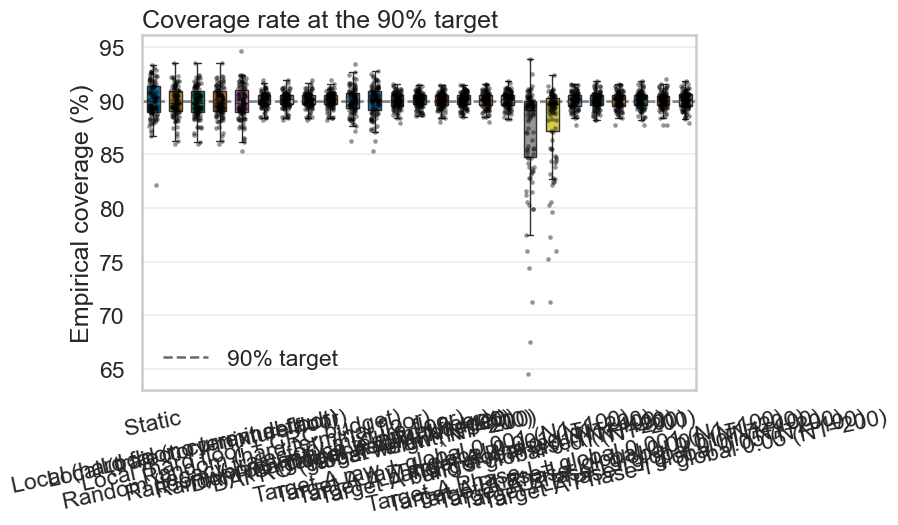

Saved: C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\lpb_90pct_method_metrics\figure_coverage_rate.png
Saved: C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\lpb_90pct_method_metrics\figure_coverage_rate.pdf


### Coverage rate

| Method | Mean coverage (%) | Median coverage (%) | Coverage SD (pp) | Min coverage (%) | Max coverage (%) | Replicates | Splits meeting target (%) | Mean coverage meets target |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Static | 90.06 | 89.93 | 1.75 | 82.17 | 93.30 | 100 | 50.0 | Yes |
| Local (hard floor; current default) | 89.89 | 89.75 | 1.40 | 85.93 | 93.53 | 100 | 48.0 | No |
| Local (trajectory-mixture floor) | 89.86 | 89.80 | 1.44 | 85.93 | 93.53 | 100 | 47.0 | No |
| Local (no terminal floor) | 89.89 | 89.75 | 1.40 | 85.93 | 93.53 | 100 | 48.0 | No |
| Local (hard floor + CRC budget) | 89.88 | 89.83 | 1.57 | 85.30 | 94.60 | 100 | 49.0 | No |
| Random (legacy trajectory-mixture floor) | 90.09 | 90.17 | 0.72 | 88.20 | 91.93 | 100 | 59.0 | Yes |
| Random (hard terminal floor) | 90.09 | 90.17 | 0.72 | 88.20 | 91.93 | 100 | 59.0 | Yes |
| Random (constant; no terminal floor) | 90.09 | 90.18 | 0.71 | 88.20 | 91.93 | 100 | 60.0 | Yes |
| Random (hard floor + CRC budget) | 90.09 | 90.13 | 0.72 | 88.20 | 91.93 | 100 | 61.0 | Yes |
| DAPRO (global weight; N1=100) | 89.98 | 89.95 | 1.21 | 86.27 | 93.47 | 100 | 50.0 | Yes |
| DAPRO (global weight; N1=200) | 89.97 | 90.08 | 1.39 | 85.30 | 92.77 | 100 | 60.0 | Yes |
| Target-A raw (N1=100) | 90.03 | 90.03 | 0.72 | 87.97 | 91.57 | 100 | 55.0 | Yes |
| Target-A raw (N1=200) | 90.09 | 90.12 | 0.67 | 88.57 | 91.47 | 100 | 62.0 | Yes |
| Target-A raw + global 0.001 (N1=100) | 90.05 | 90.07 | 0.72 | 88.00 | 91.47 | 100 | 57.0 | Yes |
| Target-A raw + global 0.001 (N1=200) | 90.11 | 90.17 | 0.68 | 88.47 | 91.47 | 100 | 62.0 | Yes |
| Target-A band + global 0.01 (N1=100) | 90.08 | 90.10 | 0.72 | 88.00 | 91.53 | 100 | 62.0 | Yes |
| Target-A band + global 0.01 (N1=200) | 90.09 | 90.18 | 0.73 | 88.27 | 91.80 | 100 | 58.0 | Yes |
| Target-A Phase-I (N1=100) | 86.89 | 89.17 | 5.05 | 64.57 | 93.90 | 100 | 26.0 | No |
| Target-A Phase-I (N1=200) | 87.95 | 89.67 | 3.87 | 71.27 | 92.43 | 100 | 33.0 | No |
| Target-A Phase-I + global 0.001 (N1=100) | 90.05 | 90.13 | 0.76 | 87.73 | 91.53 | 100 | 61.0 | Yes |
| Target-A Phase-I + global 0.001 (N1=200) | 90.04 | 90.08 | 0.78 | 88.17 | 91.87 | 100 | 55.0 | Yes |
| Target-A Phase-I + global 0.01 (N1=100) | 90.06 | 90.17 | 0.76 | 87.73 | 91.53 | 100 | 62.0 | Yes |
| Target-A Phase-I + global 0.01 (N1=200) | 90.04 | 90.03 | 0.77 | 87.77 | 91.87 | 100 | 55.0 | Yes |
| Target-A Phase-I + global 0.05 (N1=100) | 90.06 | 90.10 | 0.76 | 87.73 | 92.07 | 100 | 61.0 | Yes |
| Target-A Phase-I + global 0.05 (N1=200) | 90.06 | 90.03 | 0.78 | 87.93 | 91.87 | 100 | 58.0 | Yes |

Target coverage is 90%. Coverage SD is across replicates in percentage points. Feasibility flags describe held-out empirical coverage and do not redefine the formal guarantee.

Copy this block into OpenReview:

```markdown
| Method | Mean coverage (%) | Median coverage (%) | Coverage SD (pp) | Min coverage (%) | Max coverage (%) | Replicates | Splits meeting target (%) | Mean coverage meets target |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Static | 90.06 | 89.93 | 1.75 | 82.17 | 93.30 | 100 | 50.0 | Yes |
| Local (hard floor; current default) | 89.89 | 89.75 | 1.40 | 85.93 | 93.53 | 100 | 48.0 | No |
| Local (trajectory-mixture floor) | 89.86 | 89.80 | 1.44 | 85.93 | 93.53 | 100 | 47.0 | No |
| Local (no terminal floor) | 89.89 | 89.75 | 1.40 | 85.93 | 93.53 | 100 | 48.0 | No |
| Local (hard floor + CRC budget) | 89.88 | 89.83 | 1.57 | 85.30 | 94.60 | 100 | 49.0 | No |
| Random (legacy trajectory-mixture floor) | 90.09 | 90.17 | 0.72 | 88.20 | 91.93 | 100 | 59.0 | Yes |
| Random (hard terminal floor) | 90.09 | 90.17 | 0.72 | 88.20 | 91.93 | 100 | 59.0 | Yes |
| Random (constant; no terminal floor) | 90.09 | 90.18 | 0.71 | 88.20 | 91.93 | 100 | 60.0 | Y

In [4]:
coverage_table = (
    analysis_df.groupby("Method", observed=True)["coverage_pct"]
    .agg(**{
        "Mean coverage (%)": "mean",
        "Median coverage (%)": "median",
        "Coverage SD (pp)": "std",
        "Min coverage (%)": "min",
        "Max coverage (%)": "max",
        "Replicates": "count",
    })
    .reindex(METHOD_ORDER)
    .reset_index()
)
split_coverage_feasibility = (
    100.0
    * analysis_df.groupby("Method", observed=True)["coverage_meets_target"].mean()
)
coverage_table["Splits meeting target (%)"] = coverage_table["Method"].map(
    split_coverage_feasibility
)
coverage_table["Mean coverage meets target"] = np.where(
    coverage_table["Mean coverage (%)"] + 100 * TARGET_ATOL
    >= 100 * TARGET_COVERAGE,
    "Yes",
    "No",
)

_boxplot(
    analysis_df,
    y="coverage_pct",
    ylabel="Empirical coverage (%)",
    title="Coverage rate at the 90% target",
    slug="coverage_rate",
    reference=100 * TARGET_COVERAGE,
    reference_label="90% target",
)

coverage_md = _publish_table(
    "Coverage rate",
    coverage_table,
    formats={
        "Method": str,
        "Mean coverage (%)": lambda x: _format_number(x, 2),
        "Median coverage (%)": lambda x: _format_number(x, 2),
        "Coverage SD (pp)": lambda x: _format_number(x, 2),
        "Min coverage (%)": lambda x: _format_number(x, 2),
        "Max coverage (%)": lambda x: _format_number(x, 2),
        "Splits meeting target (%)": lambda x: _format_number(x, 1),
        "Mean coverage meets target": str,
        "Replicates": lambda x: str(int(x)),
    },
    slug="coverage_rate",
    note=(
        f"Target coverage is {100 * TARGET_COVERAGE:.0f}%. Coverage SD is across "
        "replicates in percentage points. Feasibility flags describe held-out "
        "empirical coverage and do not redefine the formal guarantee."
    ),
)
openreview_sections.append(("Coverage rate", coverage_md))

## 2. Coverage-rate deviation from target

Deviation is **signed**: empirical coverage minus the 90% target, measured in percentage points. Positive values indicate overcoverage; negative values indicate undercoverage. The table also includes mean absolute deviation to make distance from the target explicit.


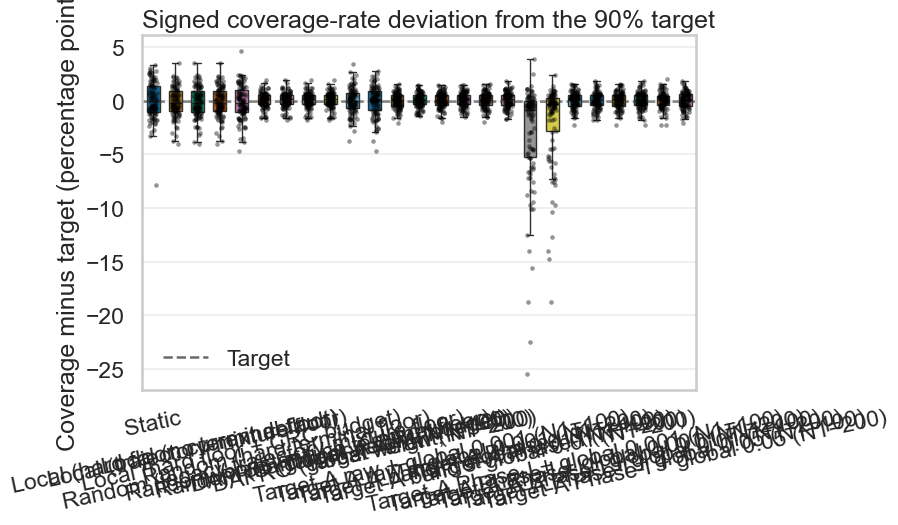

Saved: C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\lpb_90pct_method_metrics\figure_coverage_deviation.png
Saved: C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\lpb_90pct_method_metrics\figure_coverage_deviation.pdf


### Coverage-rate deviation from target

| Method | Mean deviation (pp) | Median deviation (pp) | Mean absolute deviation (pp) | RMSE from target (pp) | Replicates |
|---|---:|---:|---:|---:|---:|
| Static | +0.06 | -0.07 | 1.39 | 1.74 | 100 |
| Local (hard floor; current default) | -0.11 | -0.25 | 1.12 | 1.39 | 100 |
| Local (trajectory-mixture floor) | -0.14 | -0.20 | 1.17 | 1.44 | 100 |
| Local (no terminal floor) | -0.11 | -0.25 | 1.12 | 1.39 | 100 |
| Local (hard floor + CRC budget) | -0.12 | -0.17 | 1.25 | 1.57 | 100 |
| Random (legacy trajectory-mixture floor) | +0.09 | +0.17 | 0.57 | 0.72 | 100 |
| Random (hard terminal floor) | +0.09 | +0.17 | 0.57 | 0.72 | 100 |
| Random (constant; no terminal floor) | +0.09 | +0.18 | 0.57 | 0.71 | 100 |
| Random (hard floor + CRC budget) | +0.09 | +0.13 | 0.57 | 0.72 | 100 |
| DAPRO (global weight; N1=100) | -0.02 | -0.05 | 0.94 | 1.21 | 100 |
| DAPRO (global weight; N1=200) | -0.03 | +0.08 | 1.07 | 1.39 | 100 |
| Target-A raw (N1=100) | +0.03 | +0.03 | 0.57 | 0.72 | 100 |
| Target-A raw (N1=200) | +0.09 | +0.12 | 0.55 | 0.67 | 100 |
| Target-A raw + global 0.001 (N1=100) | +0.05 | +0.07 | 0.58 | 0.72 | 100 |
| Target-A raw + global 0.001 (N1=200) | +0.11 | +0.17 | 0.56 | 0.68 | 100 |
| Target-A band + global 0.01 (N1=100) | +0.08 | +0.10 | 0.57 | 0.72 | 100 |
| Target-A band + global 0.01 (N1=200) | +0.09 | +0.18 | 0.61 | 0.74 | 100 |
| Target-A Phase-I (N1=100) | -3.11 | -0.83 | 3.48 | 5.90 | 100 |
| Target-A Phase-I (N1=200) | -2.05 | -0.33 | 2.41 | 4.36 | 100 |
| Target-A Phase-I + global 0.001 (N1=100) | +0.05 | +0.13 | 0.61 | 0.76 | 100 |
| Target-A Phase-I + global 0.001 (N1=200) | +0.04 | +0.08 | 0.63 | 0.78 | 100 |
| Target-A Phase-I + global 0.01 (N1=100) | +0.06 | +0.17 | 0.61 | 0.76 | 100 |
| Target-A Phase-I + global 0.01 (N1=200) | +0.04 | +0.03 | 0.61 | 0.77 | 100 |
| Target-A Phase-I + global 0.05 (N1=100) | +0.06 | +0.10 | 0.58 | 0.76 | 100 |
| Target-A Phase-I + global 0.05 (N1=200) | +0.06 | +0.03 | 0.63 | 0.78 | 100 |

Deviation is empirical coverage minus 90%, in percentage points; positive values are overcoverage.

Copy this block into OpenReview:

```markdown
| Method | Mean deviation (pp) | Median deviation (pp) | Mean absolute deviation (pp) | RMSE from target (pp) | Replicates |
|---|---:|---:|---:|---:|---:|
| Static | +0.06 | -0.07 | 1.39 | 1.74 | 100 |
| Local (hard floor; current default) | -0.11 | -0.25 | 1.12 | 1.39 | 100 |
| Local (trajectory-mixture floor) | -0.14 | -0.20 | 1.17 | 1.44 | 100 |
| Local (no terminal floor) | -0.11 | -0.25 | 1.12 | 1.39 | 100 |
| Local (hard floor + CRC budget) | -0.12 | -0.17 | 1.25 | 1.57 | 100 |
| Random (legacy trajectory-mixture floor) | +0.09 | +0.17 | 0.57 | 0.72 | 100 |
| Random (hard terminal floor) | +0.09 | +0.17 | 0.57 | 0.72 | 100 |
| Random (constant; no terminal floor) | +0.09 | +0.18 | 0.57 | 0.71 | 100 |
| Random (hard floor + CRC budget) | +0.09 | +0.13 | 0.57 | 0.72 | 100 |
| DAPRO (global weight; N1=100) | -0.02 | -0.05 | 0.94 | 1.21 | 100 |
| DAPRO (global weight; N1=200) | -0.03 | +0.08 | 1.07 | 1.39 | 100 |
| Target-A raw (N1=100) 

In [5]:
deviation_table = (
    analysis_df.groupby("Method", observed=True)["coverage_deviation_pp"]
    .agg(**{
        "Mean deviation (pp)": "mean",
        "Median deviation (pp)": "median",
        "Mean absolute deviation (pp)": lambda x: x.abs().mean(),
        "RMSE from target (pp)": lambda x: np.sqrt(np.mean(np.square(x))),
        "Replicates": "count",
    })
    .reindex(METHOD_ORDER)
    .reset_index()
)

_boxplot(
    analysis_df,
    y="coverage_deviation_pp",
    ylabel="Coverage minus target (percentage points)",
    title="Signed coverage-rate deviation from the 90% target",
    slug="coverage_deviation",
    reference=0.0,
    reference_label="Target",
)

deviation_md = _publish_table(
    "Coverage-rate deviation from target",
    deviation_table,
    formats={
        "Method": str,
        "Mean deviation (pp)": lambda x: _format_number(x, 2, signed=True),
        "Median deviation (pp)": lambda x: _format_number(x, 2, signed=True),
        "Mean absolute deviation (pp)": lambda x: _format_number(x, 2),
        "RMSE from target (pp)": lambda x: _format_number(x, 2),
        "Replicates": lambda x: str(int(x)),
    },
    slug="coverage_deviation",
    note="Deviation is empirical coverage minus 90%, in percentage points; positive values are overcoverage.",
)
openreview_sections.append(("Coverage-rate deviation", deviation_md))

## 3. Coverage variance

The figure shows per-replicate unbiased-variance contributions: squared deviations from each method's mean multiplied by $n/(n-1)$. Their mean equals the table's unbiased sample variance across replicates in percentage-point squared.


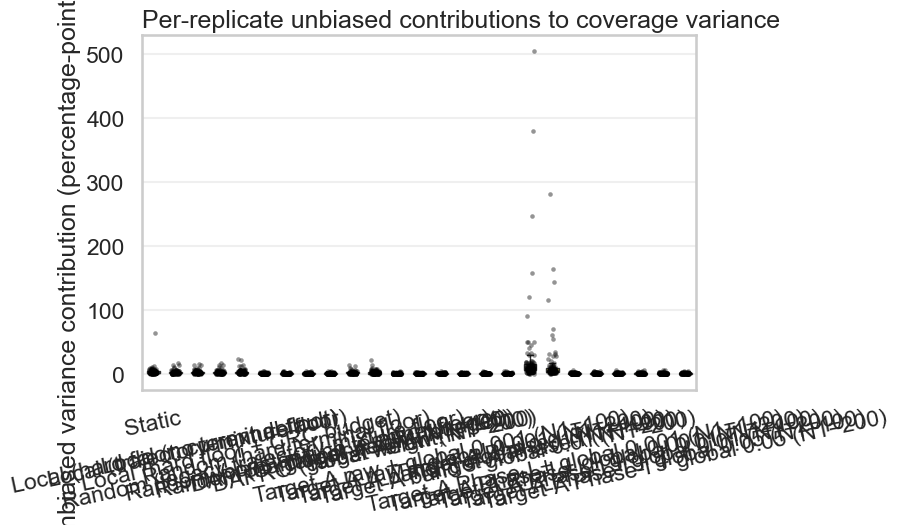

Saved: C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\lpb_90pct_method_metrics\figure_coverage_variance.png
Saved: C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\lpb_90pct_method_metrics\figure_coverage_variance.pdf


### Coverage variance

| Method | Coverage variance (pp²) | Coverage SD (pp) | Mean coverage (%) | Replicates |
|---|---:|---:|---:|---:|
| Static | 3.062 | 1.750 | 90.06 | 100 |
| Local (hard floor; current default) | 1.950 | 1.396 | 89.89 | 100 |
| Local (trajectory-mixture floor) | 2.064 | 1.436 | 89.86 | 100 |
| Local (no terminal floor) | 1.950 | 1.396 | 89.89 | 100 |
| Local (hard floor + CRC budget) | 2.477 | 1.574 | 89.88 | 100 |
| Random (legacy trajectory-mixture floor) | 0.513 | 0.716 | 90.09 | 100 |
| Random (hard terminal floor) | 0.512 | 0.715 | 90.09 | 100 |
| Random (constant; no terminal floor) | 0.506 | 0.711 | 90.09 | 100 |
| Random (hard floor + CRC budget) | 0.514 | 0.717 | 90.09 | 100 |
| DAPRO (global weight; N1=100) | 1.473 | 1.214 | 89.98 | 100 |
| DAPRO (global weight; N1=200) | 1.938 | 1.392 | 89.97 | 100 |
| Target-A raw (N1=100) | 0.517 | 0.719 | 90.03 | 100 |
| Target-A raw (N1=200) | 0.447 | 0.669 | 90.09 | 100 |
| Target-A raw + global 0.001 (N1=100) | 0.521 | 0.722 | 90.05 | 100 |
| Target-A raw + global 0.001 (N1=200) | 0.458 | 0.677 | 90.11 | 100 |
| Target-A band + global 0.01 (N1=100) | 0.518 | 0.719 | 90.08 | 100 |
| Target-A band + global 0.01 (N1=200) | 0.538 | 0.733 | 90.09 | 100 |
| Target-A Phase-I (N1=100) | 25.480 | 5.048 | 86.89 | 100 |
| Target-A Phase-I (N1=200) | 14.939 | 3.865 | 87.95 | 100 |
| Target-A Phase-I + global 0.001 (N1=100) | 0.580 | 0.762 | 90.05 | 100 |
| Target-A Phase-I + global 0.001 (N1=200) | 0.611 | 0.781 | 90.04 | 100 |
| Target-A Phase-I + global 0.01 (N1=100) | 0.578 | 0.761 | 90.06 | 100 |
| Target-A Phase-I + global 0.01 (N1=200) | 0.598 | 0.773 | 90.04 | 100 |
| Target-A Phase-I + global 0.05 (N1=100) | 0.574 | 0.758 | 90.06 | 100 |
| Target-A Phase-I + global 0.05 (N1=200) | 0.615 | 0.784 | 90.06 | 100 |

Variance is the across-replicate unbiased sample variance (`ddof=1`) of coverage measured in percentage points.

Copy this block into OpenReview:

```markdown
| Method | Coverage variance (pp²) | Coverage SD (pp) | Mean coverage (%) | Replicates |
|---|---:|---:|---:|---:|
| Static | 3.062 | 1.750 | 90.06 | 100 |
| Local (hard floor; current default) | 1.950 | 1.396 | 89.89 | 100 |
| Local (trajectory-mixture floor) | 2.064 | 1.436 | 89.86 | 100 |
| Local (no terminal floor) | 1.950 | 1.396 | 89.89 | 100 |
| Local (hard floor + CRC budget) | 2.477 | 1.574 | 89.88 | 100 |
| Random (legacy trajectory-mixture floor) | 0.513 | 0.716 | 90.09 | 100 |
| Random (hard terminal floor) | 0.512 | 0.715 | 90.09 | 100 |
| Random (constant; no terminal floor) | 0.506 | 0.711 | 90.09 | 100 |
| Random (hard floor + CRC budget) | 0.514 | 0.717 | 90.09 | 100 |
| DAPRO (global weight; N1=100) | 1.473 | 1.214 | 89.98 | 100 |
| DAPRO (global weight; N1=200) | 1.938 | 1.392 | 89.97 | 100 |
| Target-A raw (N1=100) | 0.517 | 0.719 | 90.03 | 100 |
| Target-A raw (N1=200) | 0.447 | 0.669 | 90.09 | 100 |
| Target-A raw + gl

In [6]:
coverage_variance_table = (
    analysis_df.groupby("Method", observed=True)["coverage_pct"]
    .agg(**{
        "Coverage variance (pp²)": lambda x: x.var(ddof=1),
        "Coverage SD (pp)": lambda x: x.std(ddof=1),
        "Mean coverage (%)": "mean",
        "Replicates": "count",
    })
    .reindex(METHOD_ORDER)
    .reset_index()
)

_boxplot(
    analysis_df,
    y="coverage_sq_deviation_pp2",
    ylabel="Unbiased variance contribution (percentage-points squared)",
    title="Per-replicate unbiased contributions to coverage variance",
    slug="coverage_variance",
)

coverage_variance_md = _publish_table(
    "Coverage variance",
    coverage_variance_table,
    formats={
        "Method": str,
        "Coverage variance (pp²)": lambda x: _format_number(x, 3),
        "Coverage SD (pp)": lambda x: _format_number(x, 3),
        "Mean coverage (%)": lambda x: _format_number(x, 2),
        "Replicates": lambda x: str(int(x)),
    },
    slug="coverage_variance",
    note="Variance is the across-replicate unbiased sample variance (`ddof=1`) of coverage measured in percentage points.",
)
openreview_sections.append(("Coverage variance", coverage_variance_md))

## 4. LPB variance

`size` is treated as the split-level mean LPB size. Each plotted squared deviation is multiplied by $n/(n-1)$, so the mean contribution equals the unbiased sample variance in the table.


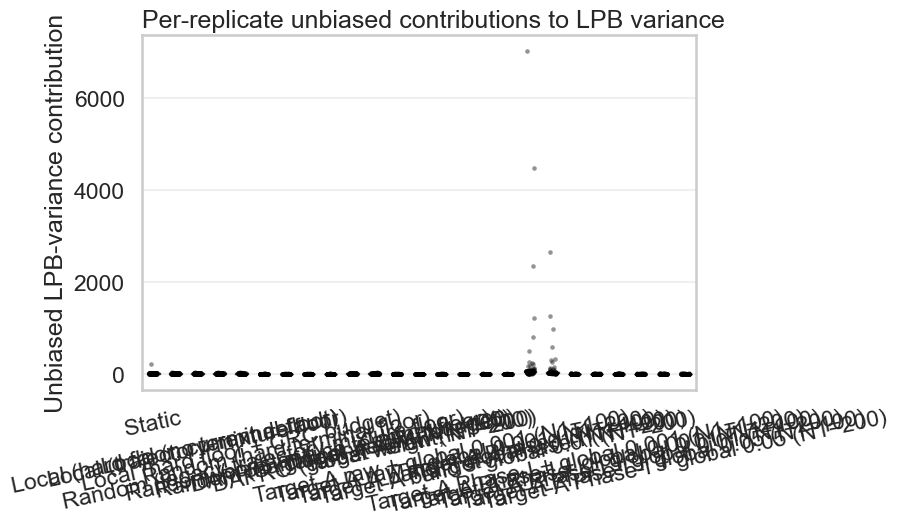

Saved: C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\lpb_90pct_method_metrics\figure_lpb_variance.png
Saved: C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\lpb_90pct_method_metrics\figure_lpb_variance.pdf


### LPB variance

| Method | LPB variance | LPB SD | Mean LPB size | Median LPB size | Replicates |
|---|---:|---:|---:|---:|---:|
| Static | 5.339 | 2.311 | 6.577 | 6.562 | 100 |
| Local (hard floor; current default) | 2.770 | 1.664 | 6.618 | 6.599 | 100 |
| Local (trajectory-mixture floor) | 2.864 | 1.692 | 6.670 | 6.658 | 100 |
| Local (no terminal floor) | 2.770 | 1.664 | 6.618 | 6.599 | 100 |
| Local (hard floor + CRC budget) | 3.370 | 1.836 | 6.687 | 6.617 | 100 |
| Random (legacy trajectory-mixture floor) | 0.283 | 0.532 | 6.238 | 6.207 | 100 |
| Random (hard terminal floor) | 0.283 | 0.532 | 6.236 | 6.201 | 100 |
| Random (constant; no terminal floor) | 0.269 | 0.519 | 6.228 | 6.166 | 100 |
| Random (hard floor + CRC budget) | 0.284 | 0.533 | 6.229 | 6.170 | 100 |
| DAPRO (global weight; N1=100) | 1.958 | 1.399 | 6.472 | 6.379 | 100 |
| DAPRO (global weight; N1=200) | 2.766 | 1.663 | 6.503 | 6.159 | 100 |
| Target-A raw (N1=100) | 0.244 | 0.494 | 6.310 | 6.342 | 100 |
| Target-A raw (N1=200) | 0.185 | 0.430 | 6.221 | 6.175 | 100 |
| Target-A raw + global 0.001 (N1=100) | 0.256 | 0.506 | 6.279 | 6.300 | 100 |
| Target-A raw + global 0.001 (N1=200) | 0.208 | 0.456 | 6.199 | 6.164 | 100 |
| Target-A band + global 0.01 (N1=100) | 0.264 | 0.514 | 6.233 | 6.253 | 100 |
| Target-A band + global 0.01 (N1=200) | 0.326 | 0.571 | 6.220 | 6.176 | 100 |
| Target-A Phase-I (N1=100) | 210.482 | 14.508 | 13.499 | 6.929 | 100 |
| Target-A Phase-I (N1=200) | 85.376 | 9.240 | 10.663 | 6.717 | 100 |
| Target-A Phase-I + global 0.001 (N1=100) | 0.493 | 0.702 | 6.290 | 6.274 | 100 |
| Target-A Phase-I + global 0.001 (N1=200) | 0.476 | 0.690 | 6.303 | 6.382 | 100 |
| Target-A Phase-I + global 0.01 (N1=100) | 0.490 | 0.700 | 6.273 | 6.220 | 100 |
| Target-A Phase-I + global 0.01 (N1=200) | 0.488 | 0.699 | 6.317 | 6.365 | 100 |
| Target-A Phase-I + global 0.05 (N1=100) | 0.497 | 0.705 | 6.278 | 6.304 | 100 |
| Target-A Phase-I + global 0.05 (N1=200) | 0.566 | 0.752 | 6.263 | 6.304 | 100 |

LPB variance is the across-replicate unbiased sample variance (`ddof=1`) of the `size` column.

Copy this block into OpenReview:

```markdown
| Method | LPB variance | LPB SD | Mean LPB size | Median LPB size | Replicates |
|---|---:|---:|---:|---:|---:|
| Static | 5.339 | 2.311 | 6.577 | 6.562 | 100 |
| Local (hard floor; current default) | 2.770 | 1.664 | 6.618 | 6.599 | 100 |
| Local (trajectory-mixture floor) | 2.864 | 1.692 | 6.670 | 6.658 | 100 |
| Local (no terminal floor) | 2.770 | 1.664 | 6.618 | 6.599 | 100 |
| Local (hard floor + CRC budget) | 3.370 | 1.836 | 6.687 | 6.617 | 100 |
| Random (legacy trajectory-mixture floor) | 0.283 | 0.532 | 6.238 | 6.207 | 100 |
| Random (hard terminal floor) | 0.283 | 0.532 | 6.236 | 6.201 | 100 |
| Random (constant; no terminal floor) | 0.269 | 0.519 | 6.228 | 6.166 | 100 |
| Random (hard floor + CRC budget) | 0.284 | 0.533 | 6.229 | 6.170 | 100 |
| DAPRO (global weight; N1=100) | 1.958 | 1.399 | 6.472 | 6.379 | 100 |
| DAPRO (global weight; N1=200) | 2.766 | 1.663 | 6.503 | 6.159 | 100 |
| Target-A raw (N1=100) | 0.244 | 0.494 | 6.3

In [7]:
lpb_variance_table = (
    analysis_df.groupby("Method", observed=True)["size"]
    .agg(**{
        "LPB variance": lambda x: x.var(ddof=1),
        "LPB SD": lambda x: x.std(ddof=1),
        "Mean LPB size": "mean",
        "Median LPB size": "median",
        "Replicates": "count",
    })
    .reindex(METHOD_ORDER)
    .reset_index()
)

_boxplot(
    analysis_df,
    y="lpb_sq_deviation",
    ylabel="Unbiased LPB-variance contribution",
    title="Per-replicate unbiased contributions to LPB variance",
    slug="lpb_variance",
)

lpb_variance_md = _publish_table(
    "LPB variance",
    lpb_variance_table,
    formats={
        "Method": str,
        "LPB variance": lambda x: _format_number(x, 3),
        "LPB SD": lambda x: _format_number(x, 3),
        "Mean LPB size": lambda x: _format_number(x, 3),
        "Median LPB size": lambda x: _format_number(x, 3),
        "Replicates": lambda x: str(int(x)),
    },
    slug="lpb_variance",
    note="LPB variance is the across-replicate unbiased sample variance (`ddof=1`) of the `size` column.",
)
openreview_sections.append(("LPB variance", lpb_variance_md))

## 5. Mean weight and selected-bound A-weighted propensity metrics

`mean_weight` is $n^{-1}\sum_i 1/\pi_i$ over all calibration rows. For the LPB selected at 90% target coverage, this section also reports $n^{-1}\sum_i A_i/\pi_i$ and the conditional Horvitz--Thompson variance proxy $n^{-1}\sum_i A_i(1/\pi_i-1)$. Phase-I rows are fully observed and enter these all-calibration means with $\pi_i=1$.

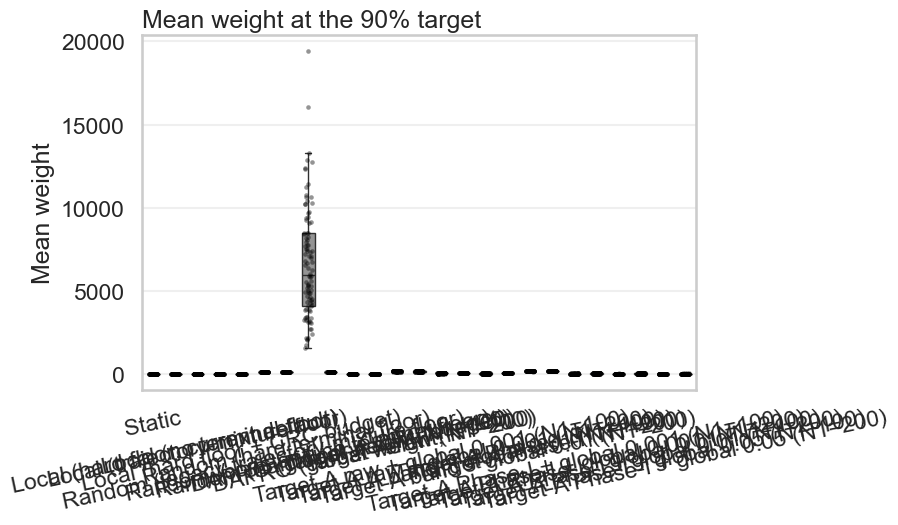

Saved: C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\lpb_90pct_method_metrics\figure_mean_weight.png
Saved: C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\lpb_90pct_method_metrics\figure_mean_weight.pdf


### Mean weight

| Method | Mean weight | Median weight | Weight SD | Min weight | Max weight | Replicates |
|---|---:|---:|---:|---:|---:|---:|
| Static | 8.656 | 8.656 | 0.025 | 8.607 | 8.717 | 100 |
| Local (hard floor; current default) | 6.657 | 6.676 | 0.494 | 5.397 | 7.827 | 100 |
| Local (trajectory-mixture floor) | 6.663 | 6.680 | 0.495 | 5.399 | 7.835 | 100 |
| Local (no terminal floor) | 6.657 | 6.676 | 0.494 | 5.397 | 7.827 | 100 |
| Local (hard floor + CRC budget) | 7.519 | 7.537 | 0.573 | 6.059 | 8.883 | 100 |
| Random (legacy trajectory-mixture floor) | 108.637 | 109.319 | 2.868 | 101.106 | 114.987 | 100 |
| Random (hard terminal floor) | 115.629 | 116.066 | 2.297 | 110.385 | 120.913 | 100 |
| Random (constant; no terminal floor) | 6602.786 | 5958.546 | 3307.505 | 1524.305 | 19399.291 | 100 |
| Random (hard floor + CRC budget) | 120.141 | 120.434 | 2.059 | 115.313 | 124.369 | 100 |
| DAPRO (global weight; N1=100) | 6.876 | 6.870 | 0.505 | 5.562 | 7.996 | 100 |
| DAPRO (global weight; N1=200) | 8.504 | 8.463 | 0.661 | 6.837 | 10.323 | 100 |
| Target-A raw (N1=100) | 145.919 | 150.919 | 19.109 | 90.628 | 173.798 | 100 |
| Target-A raw (N1=200) | 134.446 | 139.471 | 17.192 | 89.152 | 160.532 | 100 |
| Target-A raw + global 0.001 (N1=100) | 16.431 | 16.689 | 4.958 | 7.642 | 29.401 | 100 |
| Target-A raw + global 0.001 (N1=200) | 25.781 | 27.233 | 5.140 | 12.681 | 39.045 | 100 |
| Target-A band + global 0.01 (N1=100) | 10.698 | 10.727 | 0.925 | 8.783 | 12.743 | 100 |
| Target-A band + global 0.01 (N1=200) | 13.965 | 14.119 | 1.012 | 11.640 | 16.072 | 100 |
| Target-A Phase-I (N1=100) | 171.617 | 175.258 | 9.311 | 127.421 | 181.891 | 100 |
| Target-A Phase-I (N1=200) | 162.698 | 164.246 | 9.039 | 134.055 | 176.054 | 100 |
| Target-A Phase-I + global 0.001 (N1=100) | 8.960 | 7.940 | 2.875 | 6.108 | 21.300 | 100 |
| Target-A Phase-I + global 0.001 (N1=200) | 13.097 | 11.535 | 4.513 | 7.746 | 32.146 | 100 |
| Target-A Phase-I + global 0.01 (N1=100) | 8.177 | 7.931 | 1.188 | 6.108 | 12.052 | 100 |
| Target-A Phase-I + global 0.01 (N1=200) | 10.915 | 10.666 | 1.608 | 7.746 | 15.395 | 100 |
| Target-A Phase-I + global 0.05 (N1=100) | 7.630 | 7.604 | 0.636 | 6.021 | 9.007 | 100 |
| Target-A Phase-I + global 0.05 (N1=200) | 9.625 | 9.600 | 0.780 | 7.729 | 11.630 | 100 |

All rows are restricted to target coverage 90%.

Copy this block into OpenReview:

```markdown
| Method | Mean weight | Median weight | Weight SD | Min weight | Max weight | Replicates |
|---|---:|---:|---:|---:|---:|---:|
| Static | 8.656 | 8.656 | 0.025 | 8.607 | 8.717 | 100 |
| Local (hard floor; current default) | 6.657 | 6.676 | 0.494 | 5.397 | 7.827 | 100 |
| Local (trajectory-mixture floor) | 6.663 | 6.680 | 0.495 | 5.399 | 7.835 | 100 |
| Local (no terminal floor) | 6.657 | 6.676 | 0.494 | 5.397 | 7.827 | 100 |
| Local (hard floor + CRC budget) | 7.519 | 7.537 | 0.573 | 6.059 | 8.883 | 100 |
| Random (legacy trajectory-mixture floor) | 108.637 | 109.319 | 2.868 | 101.106 | 114.987 | 100 |
| Random (hard terminal floor) | 115.629 | 116.066 | 2.297 | 110.385 | 120.913 | 100 |
| Random (constant; no terminal floor) | 6602.786 | 5958.546 | 3307.505 | 1524.305 | 19399.291 | 100 |
| Random (hard floor + CRC budget) | 120.141 | 120.434 | 2.059 | 115.313 | 124.369 | 100 |
| DAPRO (global weight; N1=100) | 6.876 | 6.870 | 0.505 | 5.56

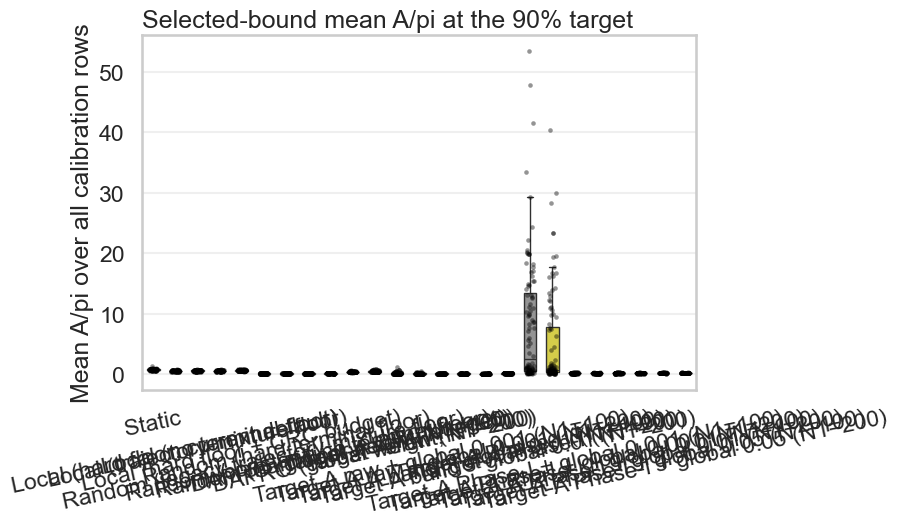

Saved: C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\lpb_90pct_method_metrics\figure_mean_a_over_pi.png
Saved: C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\lpb_90pct_method_metrics\figure_mean_a_over_pi.pdf


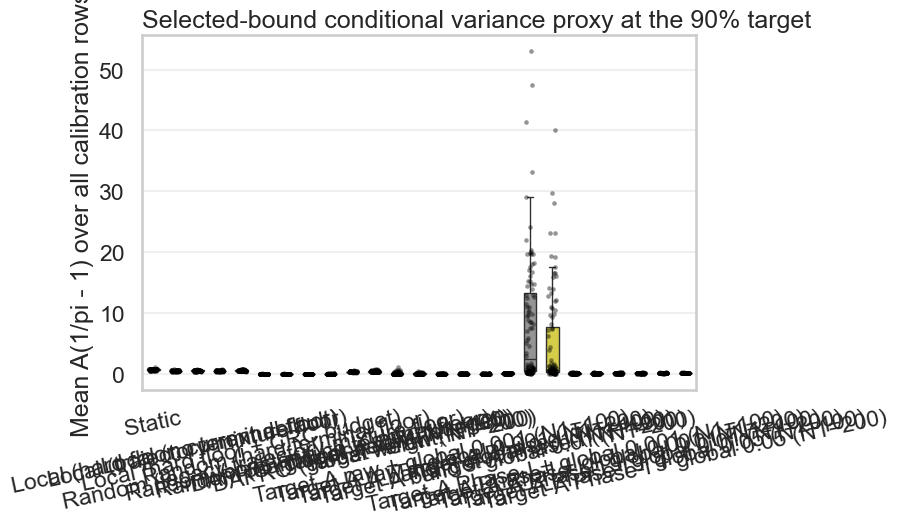

Saved: C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\lpb_90pct_method_metrics\figure_mean_a_inverse_probability_minus_one.png
Saved: C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\lpb_90pct_method_metrics\figure_mean_a_inverse_probability_minus_one.pdf


### Selected-bound A-weighted propensity metrics

| Method | Mean A | Mean A/pi | Median A/pi | Mean A(1/pi-1) | Median A(1/pi-1) | Proxy SD across splits | Replicates |
|---|---:|---:|---:|---:|---:|---:|---:|
| Static | 0.0996 | 0.7499 | 0.7508 | 0.6502 | 0.6513 | 0.1117 | 100 |
| Local (hard floor; current default) | 0.1016 | 0.5533 | 0.5480 | 0.4516 | 0.4462 | 0.0771 | 100 |
| Local (trajectory-mixture floor) | 0.1017 | 0.5581 | 0.5557 | 0.4564 | 0.4513 | 0.0783 | 100 |
| Local (no terminal floor) | 0.1016 | 0.5533 | 0.5480 | 0.4516 | 0.4462 | 0.0771 | 100 |
| Local (hard floor + CRC budget) | 0.1017 | 0.6257 | 0.6288 | 0.5240 | 0.5238 | 0.0955 | 100 |
| Random (legacy trajectory-mixture floor) | 0.0997 | 0.1110 | 0.1111 | 0.0114 | 0.0113 | 0.0013 | 100 |
| Random (hard terminal floor) | 0.0997 | 0.1108 | 0.1109 | 0.0111 | 0.0110 | 0.0012 | 100 |
| Random (constant; no terminal floor) | 0.0997 | 0.1106 | 0.1105 | 0.0110 | 0.0109 | 0.0012 | 100 |
| Random (hard floor + CRC budget) | 0.0997 | 0.1127 | 0.1125 | 0.0130 | 0.0129 | 0.0015 | 100 |
| DAPRO (global weight; N1=100) | 0.1007 | 0.3939 | 0.3810 | 0.2932 | 0.2788 | 0.0764 | 100 |
| DAPRO (global weight; N1=200) | 0.1006 | 0.4834 | 0.4482 | 0.3828 | 0.3518 | 0.1045 | 100 |
| Target-A raw (N1=100) | 0.1003 | 0.1991 | 0.1138 | 0.0989 | 0.0138 | 0.1659 | 100 |
| Target-A raw (N1=200) | 0.0997 | 0.1368 | 0.1031 | 0.0372 | 0.0036 | 0.0663 | 100 |
| Target-A raw + global 0.001 (N1=100) | 0.1000 | 0.1072 | 0.1052 | 0.0072 | 0.0057 | 0.0067 | 100 |
| Target-A raw + global 0.001 (N1=200) | 0.0996 | 0.1090 | 0.1056 | 0.0094 | 0.0059 | 0.0097 | 100 |
| Target-A band + global 0.01 (N1=100) | 0.0998 | 0.1086 | 0.1066 | 0.0088 | 0.0068 | 0.0078 | 100 |
| Target-A band + global 0.01 (N1=200) | 0.0997 | 0.1189 | 0.1157 | 0.0191 | 0.0163 | 0.0127 | 100 |
| Target-A Phase-I (N1=100) | 0.1318 | 8.1748 | 2.4602 | 8.0430 | 2.3548 | 10.4877 | 100 |
| Target-A Phase-I (N1=200) | 0.1207 | 4.9260 | 0.6993 | 4.8053 | 0.5970 | 7.8577 | 100 |
| Target-A Phase-I + global 0.001 (N1=100) | 0.1003 | 0.1487 | 0.1279 | 0.0483 | 0.0306 | 0.0522 | 100 |
| Target-A Phase-I + global 0.001 (N1=200) | 0.1003 | 0.1431 | 0.1263 | 0.0428 | 0.0269 | 0.0499 | 100 |
| Target-A Phase-I + global 0.01 (N1=100) | 0.1002 | 0.1496 | 0.1286 | 0.0494 | 0.0315 | 0.0515 | 100 |
| Target-A Phase-I + global 0.01 (N1=200) | 0.1004 | 0.1486 | 0.1345 | 0.0482 | 0.0340 | 0.0470 | 100 |
| Target-A Phase-I + global 0.05 (N1=100) | 0.1002 | 0.1626 | 0.1499 | 0.0624 | 0.0484 | 0.0434 | 100 |
| Target-A Phase-I + global 0.05 (N1=200) | 0.1001 | 0.1791 | 0.1713 | 0.0790 | 0.0709 | 0.0355 | 100 |

All three means use every calibration row. The identity `mean(A/pi) = mean(A) + mean(A(1/pi-1))` is validated before plotting. The proxy divided by calibration size is the conditional variance of the Horvitz--Thompson mean; it is not the full across-split coverage variance.

Copy this block into OpenReview:

```markdown
| Method | Mean A | Mean A/pi | Median A/pi | Mean A(1/pi-1) | Median A(1/pi-1) | Proxy SD across splits | Replicates |
|---|---:|---:|---:|---:|---:|---:|---:|
| Static | 0.0996 | 0.7499 | 0.7508 | 0.6502 | 0.6513 | 0.1117 | 100 |
| Local (hard floor; current default) | 0.1016 | 0.5533 | 0.5480 | 0.4516 | 0.4462 | 0.0771 | 100 |
| Local (trajectory-mixture floor) | 0.1017 | 0.5581 | 0.5557 | 0.4564 | 0.4513 | 0.0783 | 100 |
| Local (no terminal floor) | 0.1016 | 0.5533 | 0.5480 | 0.4516 | 0.4462 | 0.0771 | 100 |
| Local (hard floor + CRC budget) | 0.1017 | 0.6257 | 0.6288 | 0.5240 | 0.5238 | 0.0955 | 100 |
| Random (legacy trajectory-mixture floor) | 0.0997 | 0.1110 | 0.1111 | 0.0114 | 0.0113 | 0.0013 | 100 |
| Random (hard terminal floor) | 0.0997 | 0.1108 | 0.1109 | 0.0111 | 0.0110 | 0.0012 | 100 |
| Random (constant; no terminal floor) | 0.0997 | 0.1106 | 0.1105 | 0.0110 | 0.0109 | 0.0012 | 100 |
| Random (hard floor + CRC budget) | 0.0

In [8]:
mean_weight_table = (
    analysis_df.groupby("Method", observed=True)["mean_weight"]
    .agg(**{
        "Mean weight": "mean",
        "Median weight": "median",
        "Weight SD": "std",
        "Min weight": "min",
        "Max weight": "max",
        "Replicates": "count",
    })
    .reindex(METHOD_ORDER)
    .reset_index()
)

_boxplot(
    analysis_df,
    y="mean_weight",
    ylabel="Mean weight",
    title="Mean weight at the 90% target",
    slug="mean_weight",
)

mean_weight_md = _publish_table(
    "Mean weight",
    mean_weight_table,
    formats={
        "Method": str,
        "Mean weight": lambda x: _format_number(x, 3),
        "Median weight": lambda x: _format_number(x, 3),
        "Weight SD": lambda x: _format_number(x, 3),
        "Min weight": lambda x: _format_number(x, 3),
        "Max weight": lambda x: _format_number(x, 3),
        "Replicates": lambda x: str(int(x)),
    },
    slug="mean_weight",
    note=f"All rows are restricted to target coverage {100 * TARGET_COVERAGE:.0f}%.",
)
openreview_sections.append(("Mean weight", mean_weight_md))

a_weighted_table = (
    analysis_df.groupby("Method", observed=True)
    .agg(**{
        "Mean A": ("mean_a", "mean"),
        "Mean A/pi": ("mean_a_weighted_inverse_probability", "mean"),
        "Median A/pi": ("mean_a_weighted_inverse_probability", "median"),
        "Mean A(1/pi-1)": (
            "mean_a_weighted_inverse_probability_minus_one", "mean"
        ),
        "Median A(1/pi-1)": (
            "mean_a_weighted_inverse_probability_minus_one", "median"
        ),
        "Proxy SD across splits": (
            "mean_a_weighted_inverse_probability_minus_one", "std"
        ),
        "Replicates": ("seed", "count"),
    })
    .reindex(METHOD_ORDER)
    .reset_index()
)

_boxplot(
    analysis_df,
    y="mean_a_weighted_inverse_probability",
    ylabel="Mean A/pi over all calibration rows",
    title="Selected-bound mean A/pi at the 90% target",
    slug="mean_a_over_pi",
)
_boxplot(
    analysis_df,
    y="mean_a_weighted_inverse_probability_minus_one",
    ylabel="Mean A(1/pi - 1) over all calibration rows",
    title="Selected-bound conditional variance proxy at the 90% target",
    slug="mean_a_inverse_probability_minus_one",
)

a_weighted_md = _publish_table(
    "Selected-bound A-weighted propensity metrics",
    a_weighted_table,
    formats={
        "Method": str,
        "Mean A": lambda x: _format_number(x, 4),
        "Mean A/pi": lambda x: _format_number(x, 4),
        "Median A/pi": lambda x: _format_number(x, 4),
        "Mean A(1/pi-1)": lambda x: _format_number(x, 4),
        "Median A(1/pi-1)": lambda x: _format_number(x, 4),
        "Proxy SD across splits": lambda x: _format_number(x, 4),
        "Replicates": lambda x: str(int(x)),
    },
    slug="a_weighted_propensity_metrics",
    note=(
        "All three means use every calibration row. The identity "
        "`mean(A/pi) = mean(A) + mean(A(1/pi-1))` is validated before "
        "plotting. The proxy divided by calibration size is the conditional "
        "variance of the Horvitz--Thompson mean; it is not the full across-split "
        "coverage variance."
    ),
)
openreview_sections.append(("Selected-bound A-weighted metrics", a_weighted_md))

## 6. Expected-budget feasibility and realized consumption

The expected-budget constraint is checked with `total_expected_budget_per_sample` whenever it is stored. Explicitly identified legacy fallbacks use a stored static expectation or reconstruct the total from Phase-I cost and Phase-II expected cost. `budget_used / configured_cal_size` is the realized stochastic consumption and is shown separately; a realized overrun does not by itself violate an in-expectation constraint.


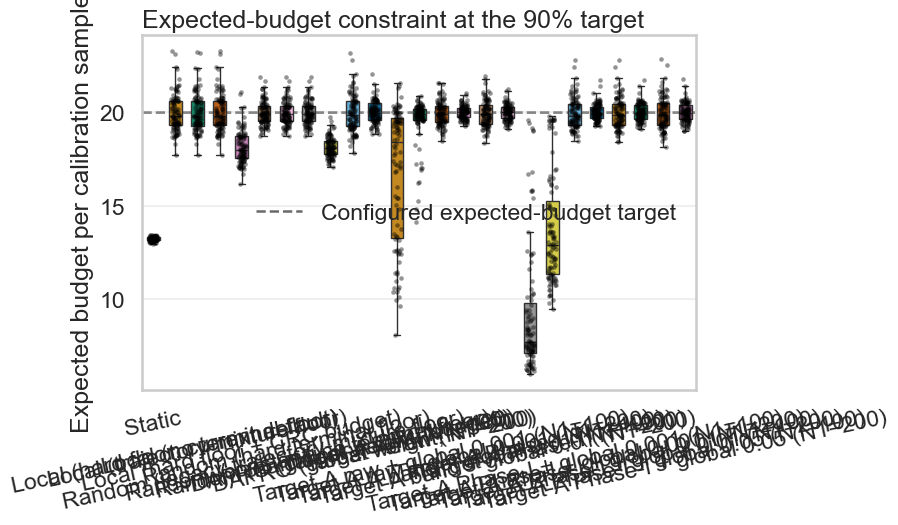

Saved: C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\lpb_90pct_method_metrics\figure_expected_budget_per_sample.png
Saved: C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\lpb_90pct_method_metrics\figure_expected_budget_per_sample.pdf


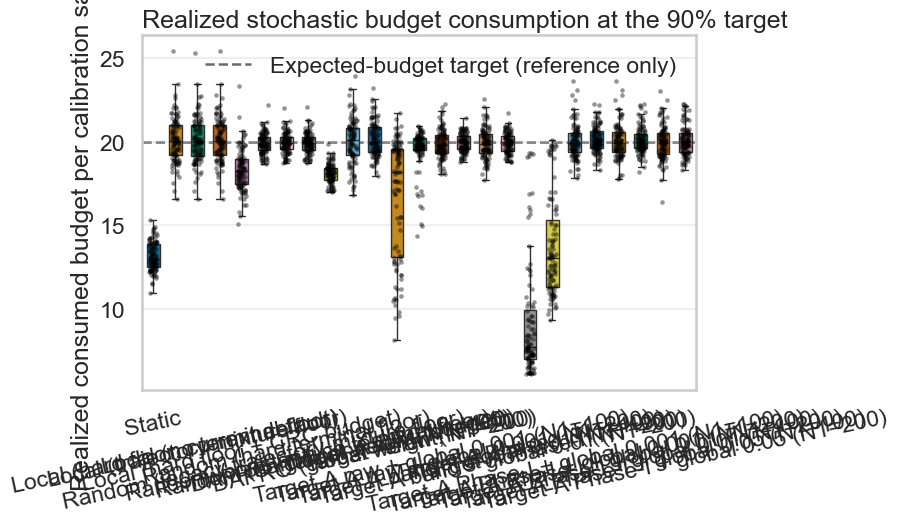

Saved: C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\lpb_90pct_method_metrics\figure_realized_budget_per_sample.png
Saved: C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\lpb_90pct_method_metrics\figure_realized_budget_per_sample.pdf


### Expected-budget feasibility and realized consumption

| Method | Configured target / sample | Mean expected budget / sample | Max expected budget / sample | Expected-budget splits available | Mean expected budget feasible | Expected budget feasible (all splits) | Mean realized budget / sample | Max realized budget / sample | Realized splits above target (%) | Replicates |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| Static | 20.000 | 13.213 | 13.428 | 100 | Yes | Yes | 13.132 | 15.304 | 0.0 | 100 |
| Local (hard floor; current default) | 20.000 | 19.967 | 23.249 | 100 | Yes | No | 20.090 | 25.378 | 50.0 | 100 |
| Local (trajectory-mixture floor) | 20.000 | 19.967 | 23.241 | 100 | Yes | No | 20.090 | 25.262 | 49.0 | 100 |
| Local (no terminal floor) | 20.000 | 19.967 | 23.249 | 100 | Yes | No | 20.090 | 25.378 | 50.0 | 100 |
| Local (hard floor + CRC budget) | 20.000 | 18.132 | 21.055 | 100 | Yes | No | 18.272 | 23.298 | 6.0 | 100 |
| Random (legacy trajectory-mixture floor) | 20.000 | 19.956 | 21.872 | 100 | Yes | No | 19.920 | 22.153 | 44.0 | 100 |
| Random (hard terminal floor) | 20.000 | 19.957 | 21.880 | 100 | Yes | No | 19.924 | 22.029 | 44.0 | 100 |
| Random (constant; no terminal floor) | 20.000 | 19.957 | 21.883 | 100 | Yes | No | 19.929 | 22.067 | 46.0 | 100 |
| Random (hard floor + CRC budget) | 20.000 | 18.122 | 19.763 | 100 | Yes | Yes | 18.113 | 19.870 | 0.0 | 100 |
| DAPRO (global weight; N1=100) | 20.000 | 19.945 | 23.190 | 100 | Yes | No | 19.990 | 23.908 | 51.0 | 100 |
| DAPRO (global weight; N1=200) | 20.000 | 20.005 | 22.047 | 100 | No | No | 20.145 | 23.171 | 49.0 | 100 |
| Target-A raw (N1=100) | 20.000 | 16.783 | 21.559 | 100 | Yes | No | 16.738 | 21.723 | 16.0 | 100 |
| Target-A raw (N1=200) | 20.000 | 19.551 | 20.867 | 100 | Yes | No | 19.509 | 20.911 | 38.0 | 100 |
| Target-A raw + global 0.001 (N1=100) | 20.000 | 19.925 | 21.556 | 100 | Yes | No | 19.870 | 22.256 | 40.0 | 100 |
| Target-A raw + global 0.001 (N1=200) | 20.000 | 20.000 | 21.015 | 100 | No | No | 19.927 | 21.387 | 44.0 | 100 |
| Target-A band + global 0.01 (N1=100) | 20.000 | 19.927 | 21.914 | 100 | Yes | No | 19.882 | 22.526 | 44.0 | 100 |
| Target-A band + global 0.01 (N1=200) | 20.000 | 19.998 | 21.212 | 100 | Yes | No | 19.928 | 21.701 | 46.0 | 100 |
| Target-A Phase-I (N1=100) | 20.000 | 9.149 | 19.577 | 100 | Yes | Yes | 9.176 | 19.335 | 0.0 | 100 |
| Target-A Phase-I (N1=200) | 20.000 | 13.710 | 19.807 | 100 | Yes | Yes | 13.741 | 20.101 | 1.0 | 100 |
| Target-A Phase-I + global 0.001 (N1=100) | 20.000 | 19.945 | 22.802 | 100 | Yes | No | 20.021 | 23.610 | 47.0 | 100 |
| Target-A Phase-I + global 0.001 (N1=200) | 20.000 | 20.001 | 21.722 | 100 | No | No | 20.129 | 22.256 | 52.0 | 100 |
| Target-A Phase-I + global 0.01 (N1=100) | 20.000 | 19.941 | 22.802 | 100 | Yes | No | 20.036 | 23.610 | 48.0 | 100 |
| Target-A Phase-I + global 0.01 (N1=200) | 20.000 | 20.003 | 21.722 | 100 | No | No | 20.076 | 22.256 | 45.0 | 100 |
| Target-A Phase-I + global 0.05 (N1=100) | 20.000 | 19.939 | 22.843 | 100 | Yes | No | 19.939 | 23.011 | 46.0 | 100 |
| Target-A Phase-I + global 0.05 (N1=200) | 20.000 | 19.998 | 21.748 | 100 | Yes | No | 20.070 | 22.256 | 48.0 | 100 |

The mean-feasibility flag tests the requested average expected-budget constraint across splits; the all-splits flag is the stronger conditional diagnostic. `Unknown` means the legacy result did not store enough information to recover the expectation. Realized consumption is `budget_used / configured_cal_size` and is not used as the expectation.

Copy this block into OpenReview:

```markdown
| Method | Configured target / sample | Mean expected budget / sample | Max expected budget / sample | Expected-budget splits available | Mean expected budget feasible | Expected budget feasible (all splits) | Mean realized budget / sample | Max realized budget / sample | Realized splits above target (%) | Replicates |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| Static | 20.000 | 13.213 | 13.428 | 100 | Yes | Yes | 13.132 | 15.304 | 0.0 | 100 |
| Local (hard floor; current default) | 20.000 | 19.967 | 23.249 | 100 | Yes | No | 20.090 | 25.378 | 50.0 | 100 |
| Local (trajectory-mixture floor) | 20.000 | 19.967 | 23.241 | 100 | Yes | No | 20.090 | 25.262 | 49.0 | 100 |
| Local (no terminal floor) | 20.000 | 19.967 | 23.249 | 100 | Yes | No | 20.090 | 25.378 | 50.0 | 100 |
| Local (hard floor + CRC budget) | 20.000 | 18.132 | 21.055 | 100 | Yes | No | 18.272 | 23.298 | 6.0 | 100 |
| Random (legacy trajectory-mixture floor) | 20.0

In [9]:
def _all_known_flags_true(values):
    if values.isna().any():
        return "Unknown"
    return "Yes" if bool(values.astype(bool).all()) else "No"


budget_table = (
    analysis_df.groupby("Method", observed=True)
    .agg(**{
        "Configured target / sample": (
            "configured_budget_per_sample", "mean"
        ),
        "Mean expected budget / sample": (
            "expected_budget_per_sample", "mean"
        ),
        "Max expected budget / sample": (
            "expected_budget_per_sample", "max"
        ),
        "Expected-budget splits available": (
            "expected_budget_per_sample", "count"
        ),
        "Expected budget feasible (all splits)": (
            "expected_budget_feasible", _all_known_flags_true
        ),
        "Mean realized budget / sample": (
            "realized_budget_per_sample", "mean"
        ),
        "Max realized budget / sample": (
            "realized_budget_per_sample", "max"
        ),
        "Realized splits above target (%)": (
            "realized_budget_exceeds_target", lambda values: 100 * values.mean()
        ),
        "Replicates": ("seed", "count"),
    })
    .reindex(METHOD_ORDER)
    .reset_index()
)

budget_table["Mean expected budget feasible"] = np.where(
    budget_table["Expected-budget splits available"].eq(0),
    "Unknown",
    np.where(
        budget_table["Mean expected budget / sample"]
        <= budget_table["Configured target / sample"] + BUDGET_ATOL,
        "Yes",
        "No",
    ),
)
budget_table.insert(
    budget_table.columns.get_loc("Expected budget feasible (all splits)"),
    "Mean expected budget feasible",
    budget_table.pop("Mean expected budget feasible"),
)

budget_target = float(analysis_df["configured_budget_per_sample"].iloc[0])
_boxplot(
    analysis_df.dropna(subset=["expected_budget_per_sample"]),
    y="expected_budget_per_sample",
    ylabel="Expected budget per calibration sample",
    title="Expected-budget constraint at the 90% target",
    slug="expected_budget_per_sample",
    reference=budget_target,
    reference_label="Configured expected-budget target",
)
_boxplot(
    analysis_df,
    y="realized_budget_per_sample",
    ylabel="Realized consumed budget per calibration sample",
    title="Realized stochastic budget consumption at the 90% target",
    slug="realized_budget_per_sample",
    reference=budget_target,
    reference_label="Expected-budget target (reference only)",
)

budget_md = _publish_table(
    "Expected-budget feasibility and realized consumption",
    budget_table,
    formats={
        "Method": str,
        "Configured target / sample": lambda x: _format_number(x, 3),
        "Mean expected budget / sample": lambda x: _format_number(x, 3),
        "Max expected budget / sample": lambda x: _format_number(x, 3),
        "Expected-budget splits available": lambda x: str(int(x)),
        "Mean expected budget feasible": str,
        "Expected budget feasible (all splits)": str,
        "Mean realized budget / sample": lambda x: _format_number(x, 3),
        "Max realized budget / sample": lambda x: _format_number(x, 3),
        "Realized splits above target (%)": lambda x: _format_number(x, 1),
        "Replicates": lambda x: str(int(x)),
    },
    slug="budget_feasibility",
    note=(
        "The mean-feasibility flag tests the requested average expected-budget "
        "constraint across splits; the all-splits flag is the stronger conditional "
        "diagnostic. `Unknown` means the legacy result did not store enough "
        "information to recover the expectation. Realized consumption is "
        "`budget_used / configured_cal_size` and is not used as the expectation."
    ),
)
openreview_sections.append(("Budget feasibility", budget_md))


## 7. Concluding OpenReview summary table

This compact table places the requested method-level results side by side. Coverage variance is the unbiased across-replicate sample variance of empirical coverage percentages. Expected-budget feasibility is evaluated against the configured per-sample target; realized stochastic consumption is reported separately.


In [10]:
concluding_table = (
    analysis_df.groupby("Method", observed=True)
    .agg(**{
        "Mean coverage (%)": ("coverage_pct", "mean"),
        "Coverage variance": ("coverage_pct", lambda x: x.var(ddof=1)),
        "Mean weight": ("mean_weight", "mean"),
        "Mean A/pi": ("mean_a_weighted_inverse_probability", "mean"),
        "Mean A(1/pi-1)": (
            "mean_a_weighted_inverse_probability_minus_one", "mean"
        ),
        "Configured budget target": (
            "configured_budget_per_sample", "mean"
        ),
        "Mean expected budget": ("expected_budget_per_sample", "mean"),
        "Expected budget feasible (all splits)": (
            "expected_budget_feasible", _all_known_flags_true
        ),
        "Mean realized budget": ("realized_budget_per_sample", "mean"),
        "Coverage splits meeting target (%)": (
            "coverage_meets_target", lambda values: 100 * values.mean()
        ),
    })
    .reindex(METHOD_ORDER)
    .reset_index()
)
concluding_table["Mean expected budget feasible"] = np.where(
    concluding_table["Mean expected budget"].isna(),
    "Unknown",
    np.where(
        concluding_table["Mean expected budget"]
        <= concluding_table["Configured budget target"] + BUDGET_ATOL,
        "Yes",
        "No",
    ),
)
concluding_table.insert(
    concluding_table.columns.get_loc("Expected budget feasible (all splits)"),
    "Mean expected budget feasible",
    concluding_table.pop("Mean expected budget feasible"),
)

concluding_md = _publish_table(
    "Concluding method comparison",
    concluding_table,
    formats={
        "Method": str,
        "Mean coverage (%)": lambda x: _format_number(x, 2),
        "Coverage variance": lambda x: _format_number(x, 2),
        "Mean weight": lambda x: _format_number(x, 3),
        "Mean A/pi": lambda x: _format_number(x, 4),
        "Mean A(1/pi-1)": lambda x: _format_number(x, 4),
        "Configured budget target": lambda x: _format_number(x, 3),
        "Mean expected budget": lambda x: _format_number(x, 3),
        "Mean expected budget feasible": str,
        "Expected budget feasible (all splits)": str,
        "Mean realized budget": lambda x: _format_number(x, 3),
        "Coverage splits meeting target (%)": lambda x: _format_number(x, 1),
    },
    slug="concluding_summary",
    note=(
        "Coverage variance is the unbiased sample variance of coverage percentages "
        "across replicates, measured in percentage-points squared. The expected "
        "budget is the constraint-relevant quantity. Mean feasibility tests the "
        "average constraint; all-splits feasibility is a stronger diagnostic. "
        "`Unknown` means a legacy result did not retain enough information to "
        "reconstruct it. Realized "
        "budget is `budget_used / configured_cal_size` and is reported separately."
    ),
)

openreview_sections.append(("Concluding method comparison", concluding_md))

### Concluding method comparison

| Method | Mean coverage (%) | Coverage variance | Mean weight | Mean A/pi | Mean A(1/pi-1) | Configured budget target | Mean expected budget | Mean expected budget feasible | Expected budget feasible (all splits) | Mean realized budget | Coverage splits meeting target (%) |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| Static | 90.06 | 3.06 | 8.656 | 0.7499 | 0.6502 | 20.000 | 13.213 | Yes | Yes | 13.132 | 50.0 |
| Local (hard floor; current default) | 89.89 | 1.95 | 6.657 | 0.5533 | 0.4516 | 20.000 | 19.967 | Yes | No | 20.090 | 48.0 |
| Local (trajectory-mixture floor) | 89.86 | 2.06 | 6.663 | 0.5581 | 0.4564 | 20.000 | 19.967 | Yes | No | 20.090 | 47.0 |
| Local (no terminal floor) | 89.89 | 1.95 | 6.657 | 0.5533 | 0.4516 | 20.000 | 19.967 | Yes | No | 20.090 | 48.0 |
| Local (hard floor + CRC budget) | 89.88 | 2.48 | 7.519 | 0.6257 | 0.5240 | 20.000 | 18.132 | Yes | No | 18.272 | 49.0 |
| Random (legacy trajectory-mixture floor) | 90.09 | 0.51 | 108.637 | 0.1110 | 0.0114 | 20.000 | 19.956 | Yes | No | 19.920 | 59.0 |
| Random (hard terminal floor) | 90.09 | 0.51 | 115.629 | 0.1108 | 0.0111 | 20.000 | 19.957 | Yes | No | 19.924 | 59.0 |
| Random (constant; no terminal floor) | 90.09 | 0.51 | 6602.786 | 0.1106 | 0.0110 | 20.000 | 19.957 | Yes | No | 19.929 | 60.0 |
| Random (hard floor + CRC budget) | 90.09 | 0.51 | 120.141 | 0.1127 | 0.0130 | 20.000 | 18.122 | Yes | Yes | 18.113 | 61.0 |
| DAPRO (global weight; N1=100) | 89.98 | 1.47 | 6.876 | 0.3939 | 0.2932 | 20.000 | 19.945 | Yes | No | 19.990 | 50.0 |
| DAPRO (global weight; N1=200) | 89.97 | 1.94 | 8.504 | 0.4834 | 0.3828 | 20.000 | 20.005 | No | No | 20.145 | 60.0 |
| Target-A raw (N1=100) | 90.03 | 0.52 | 145.919 | 0.1991 | 0.0989 | 20.000 | 16.783 | Yes | No | 16.738 | 55.0 |
| Target-A raw (N1=200) | 90.09 | 0.45 | 134.446 | 0.1368 | 0.0372 | 20.000 | 19.551 | Yes | No | 19.509 | 62.0 |
| Target-A raw + global 0.001 (N1=100) | 90.05 | 0.52 | 16.431 | 0.1072 | 0.0072 | 20.000 | 19.925 | Yes | No | 19.870 | 57.0 |
| Target-A raw + global 0.001 (N1=200) | 90.11 | 0.46 | 25.781 | 0.1090 | 0.0094 | 20.000 | 20.000 | No | No | 19.927 | 62.0 |
| Target-A band + global 0.01 (N1=100) | 90.08 | 0.52 | 10.698 | 0.1086 | 0.0088 | 20.000 | 19.927 | Yes | No | 19.882 | 62.0 |
| Target-A band + global 0.01 (N1=200) | 90.09 | 0.54 | 13.965 | 0.1189 | 0.0191 | 20.000 | 19.998 | Yes | No | 19.928 | 58.0 |
| Target-A Phase-I (N1=100) | 86.89 | 25.48 | 171.617 | 8.1748 | 8.0430 | 20.000 | 9.149 | Yes | Yes | 9.176 | 26.0 |
| Target-A Phase-I (N1=200) | 87.95 | 14.94 | 162.698 | 4.9260 | 4.8053 | 20.000 | 13.710 | Yes | Yes | 13.741 | 33.0 |
| Target-A Phase-I + global 0.001 (N1=100) | 90.05 | 0.58 | 8.960 | 0.1487 | 0.0483 | 20.000 | 19.945 | Yes | No | 20.021 | 61.0 |
| Target-A Phase-I + global 0.001 (N1=200) | 90.04 | 0.61 | 13.097 | 0.1431 | 0.0428 | 20.000 | 20.001 | No | No | 20.129 | 55.0 |
| Target-A Phase-I + global 0.01 (N1=100) | 90.06 | 0.58 | 8.177 | 0.1496 | 0.0494 | 20.000 | 19.941 | Yes | No | 20.036 | 62.0 |
| Target-A Phase-I + global 0.01 (N1=200) | 90.04 | 0.60 | 10.915 | 0.1486 | 0.0482 | 20.000 | 20.003 | No | No | 20.076 | 55.0 |
| Target-A Phase-I + global 0.05 (N1=100) | 90.06 | 0.57 | 7.630 | 0.1626 | 0.0624 | 20.000 | 19.939 | Yes | No | 19.939 | 61.0 |
| Target-A Phase-I + global 0.05 (N1=200) | 90.06 | 0.62 | 9.625 | 0.1791 | 0.0790 | 20.000 | 19.998 | Yes | No | 20.070 | 58.0 |

Coverage variance is the unbiased sample variance of coverage percentages across replicates, measured in percentage-points squared. The expected budget is the constraint-relevant quantity. Mean feasibility tests the average constraint; all-splits feasibility is a stronger diagnostic. `Unknown` means a legacy result did not retain enough information to reconstruct it. Realized budget is `budget_used / configured_cal_size` and is reported separately.

Copy this block into OpenReview:

```markdown
| Method | Mean coverage (%) | Coverage variance | Mean weight | Mean A/pi | Mean A(1/pi-1) | Configured budget target | Mean expected budget | Mean expected budget feasible | Expected budget feasible (all splits) | Mean realized budget | Coverage splits meeting target (%) |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| Static | 90.06 | 3.06 | 8.656 | 0.7499 | 0.6502 | 20.000 | 13.213 | Yes | Yes | 13.132 | 50.0 |
| Local (hard floor; current default) | 89.89 | 1.95 | 6.657 | 0.5533 | 0.4516 | 20.000 | 19.967 | Yes | No | 20.090 | 48.0 |
| Local (trajectory-mixture floor) | 89.86 | 2.06 | 6.663 | 0.5581 | 0.4564 | 20.000 | 19.967 | Yes | No | 20.090 | 47.0 |
| Local (no terminal floor) | 89.89 | 1.95 | 6.657 | 0.5533 | 0.4516 | 20.000 | 19.967 | Yes | No | 20.090 | 48.0 |
| Local (hard floor + CRC budget) | 89.88 | 2.48 | 7.519 | 0.6257 | 0.5240 | 20.000 | 18.132 | Yes | No | 18.272 | 49.0 |
| Random (legacy trajectory-mixt

## Export all OpenReview tables together


In [11]:
combined_markdown_parts = []
for title, markdown in openreview_sections:
    combined_markdown_parts.extend([f"### {title}", "", markdown, ""])
combined_markdown = "\n".join(combined_markdown_parts).rstrip() + "\n"
combined_path = OUTPUT_DIR / "openreview_tables.md"
combined_path.write_text(combined_markdown, encoding="utf-8")

print("Combined OpenReview Markdown:\n")
print("```markdown")
print(combined_markdown.rstrip())
print("```")
print(f"\nSaved all tables to: {combined_path}")

artifact_rows = []
for title, figure_slug, table_slug in [
    ("Coverage rate", "coverage_rate", "coverage_rate"),
    ("Coverage-rate deviation", "coverage_deviation", "coverage_deviation"),
    ("Coverage variance", "coverage_variance", "coverage_variance"),
    ("LPB variance", "lpb_variance", "lpb_variance"),
    ("Mean weight", "mean_weight", "mean_weight"),
    ("Mean A/pi", "mean_a_over_pi", "a_weighted_propensity_metrics"),
    (
        "Mean A(1/pi-1)",
        "mean_a_inverse_probability_minus_one",
        "a_weighted_propensity_metrics",
    ),
    (
        "Expected budget per sample",
        "expected_budget_per_sample",
        "budget_feasibility",
    ),
    (
        "Realized budget per sample",
        "realized_budget_per_sample",
        "budget_feasibility",
    ),
]:
    artifact_rows.append({
        "Metric": title,
        "PNG": str(OUTPUT_DIR / f"figure_{figure_slug}.png"),
        "PDF": str(OUTPUT_DIR / f"figure_{figure_slug}.pdf"),
        "Markdown table": str(OUTPUT_DIR / f"table_{table_slug}.md"),
    })

artifact_rows.append({
    "Metric": "Concluding method comparison",
    "PNG": "—",
    "PDF": "—",
    "Markdown table": str(OUTPUT_DIR / "table_concluding_summary.md"),
})

artifact_index = pd.DataFrame(artifact_rows)
display(artifact_index)


Combined OpenReview Markdown:

```markdown
### Coverage rate

| Method | Mean coverage (%) | Median coverage (%) | Coverage SD (pp) | Min coverage (%) | Max coverage (%) | Replicates | Splits meeting target (%) | Mean coverage meets target |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Static | 90.06 | 89.93 | 1.75 | 82.17 | 93.30 | 100 | 50.0 | Yes |
| Local (hard floor; current default) | 89.89 | 89.75 | 1.40 | 85.93 | 93.53 | 100 | 48.0 | No |
| Local (trajectory-mixture floor) | 89.86 | 89.80 | 1.44 | 85.93 | 93.53 | 100 | 47.0 | No |
| Local (no terminal floor) | 89.89 | 89.75 | 1.40 | 85.93 | 93.53 | 100 | 48.0 | No |
| Local (hard floor + CRC budget) | 89.88 | 89.83 | 1.57 | 85.30 | 94.60 | 100 | 49.0 | No |
| Random (legacy trajectory-mixture floor) | 90.09 | 90.17 | 0.72 | 88.20 | 91.93 | 100 | 59.0 | Yes |
| Random (hard terminal floor) | 90.09 | 90.17 | 0.72 | 88.20 | 91.93 | 100 | 59.0 | Yes |
| Random (constant; no terminal floor) | 90.09 | 90.18 | 0.71 | 88.20 | 91.93 

,Metric,PNG,PDF,Markdown table
0,Coverage rate,C:\Users\Shai1\Documents\projects\dapro_rebutt...,C:\Users\Shai1\Documents\projects\dapro_rebutt...,C:\Users\Shai1\Documents\projects\dapro_rebutt...
1,Coverage-rate deviation,C:\Users\Shai1\Documents\projects\dapro_rebutt...,C:\Users\Shai1\Documents\projects\dapro_rebutt...,C:\Users\Shai1\Documents\projects\dapro_rebutt...
2,Coverage variance,C:\Users\Shai1\Documents\projects\dapro_rebutt...,C:\Users\Shai1\Documents\projects\dapro_rebutt...,C:\Users\Shai1\Documents\projects\dapro_rebutt...
3,LPB variance,C:\Users\Shai1\Documents\projects\dapro_rebutt...,C:\Users\Shai1\Documents\projects\dapro_rebutt...,C:\Users\Shai1\Documents\projects\dapro_rebutt...
4,Mean weight,C:\Users\Shai1\Documents\projects\dapro_rebutt...,C:\Users\Shai1\Documents\projects\dapro_rebutt...,C:\Users\Shai1\Documents\projects\dapro_rebutt...
5,Mean A/pi,C:\Users\Shai1\Documents\projects\dapro_rebutt...,C:\Users\Shai1\Documents\projects\dapro_rebutt...,C:\Users\Shai1\Documents\projects\dapro_rebutt...
6,Mean A(1/pi-1),C:\Users\Shai1\Documents\projects\dapro_rebutt...,C:\Users\Shai1\Documents\projects\dapro_rebutt...,C:\Users\Shai1\Documents\projects\dapro_rebutt...
7,Expected budget per sample,C:\Users\Shai1\Documents\projects\dapro_rebutt...,C:\Users\Shai1\Documents\projects\dapro_rebutt...,C:\Users\Shai1\Documents\projects\dapro_rebutt...
8,Realized budget per sample,C:\Users\Shai1\Documents\projects\dapro_rebutt...,C:\Users\Shai1\Documents\projects\dapro_rebutt...,C:\Users\Shai1\Documents\projects\dapro_rebutt...
9,Concluding method comparison,—,—,C:\Users\Shai1\Documents\projects\dapro_rebutt...
